# Student Performance Indicator

## Life cycle of Machine Learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

#### 1) Problem Statement

- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

#### 2) Data Collection 
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetID=74977
- The data consists of 8 columns and 1000 rows.


#### 2.1 Import Data and Required Packages

Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

#### 2.2 Import the CSV Data as Pandas DataFrame

In [33]:
file_name = r"./data/stud.csv"
df = pd.read_csv(file_name)

#### Show Top 5 Records

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Shape of the dataset

In [5]:
df.shape

(1000, 8)

#### 3. Data Checks to Perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check various categories present in the different categorical column
- Check statistics of data set
- Adding more features

#### 3.1 Check Missing Values

In [6]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

There are no missing values in the data set

#### 3.2 Check Duplicates

In [7]:
df.duplicated().sum()

0

There are no duplicate values in the data set

### 3.3 Check Data Type

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race_ethnicity               1000 non-null   object 
 2   parental_level_of_education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test_preparation_course      1000 non-null   object 
 5   math_score                   1000 non-null   int64  
 6   reading_score                1000 non-null   int64  
 7   writing_score                1000 non-null   int64  
 8   total_score                  1000 non-null   int64  
 9   average                      1000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 78.2+ KB


#### 3.3.1 Create class to store the names of variables

In [34]:
import utils
import importlib
importlib.reload(utils)
from utils import Variables

#### 3.4 Checking the number of unique values of each column

In [10]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

#### 3.5 Show unique values

In [11]:
dataset_unique_values = {col:df[col].unique() for col in df.columns}
for col, uniques in dataset_unique_values.items():
    print(f"{col} -> {uniques}")

gender -> ['female' 'male']
race_ethnicity -> ['group B' 'group C' 'group A' 'group D' 'group E']
parental_level_of_education -> ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
lunch -> ['standard' 'free/reduced']
test_preparation_course -> ['none' 'completed']
math_score -> [ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23   8]
reading_score -> [ 72  90  95  57  78  83  43  64  60  54  52  81  53  75  89  32  42  58
  69  73  71  74  70  65  87  56  61  84  55  44  41  85  59  17  39  80
  37  63  51  49  26  68  45  47  86  34  79  66  67  91 100  76  77  82
  92  93  62  88  50  28  48  46  23  38  94  97  99  31  96  24  29  40]
writing_score -> [ 74 

#### 3.6 Check statistics of data set

In [12]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 69.2;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading it is yet higher = 17

### 3.7 Adding columns for "Total Score" and "Average"

In [35]:
vars = Variables(df)
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total_score']/3
vars.refresh() # Refresh and optimize
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666664
1,female,group C,some college,standard,completed,69,90,88,247,82.333336
2,female,group B,master's degree,standard,none,90,95,93,278,92.666664
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333332
4,male,group C,some college,standard,none,76,78,75,229,76.333336


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   gender                       1000 non-null   category
 1   race_ethnicity               1000 non-null   category
 2   parental_level_of_education  1000 non-null   category
 3   lunch                        1000 non-null   category
 4   test_preparation_course      1000 non-null   category
 5   math_score                   1000 non-null   int8    
 6   reading_score                1000 non-null   int8    
 7   writing_score                1000 non-null   int8    
 8   total_score                  1000 non-null   int16   
 9   average                      1000 non-null   float32 
dtypes: category(5), float32(1), int16(1), int8(3)
memory usage: 14.6 KB


#### 4. Exploring Data (Visualization)

**Functions to Draw Graphs**

In [36]:
# Function to collect a categorical/numerical variable from the list of categorical or numerical variables

# Keep a global copy of the categorical variables and numerical variables generator
_categorical_gen = None
_numerical_gen  = None
_object_gen = None

def get_variable(data_type, state):

    """
    Generator to yield categorical variables one by one.
    state=1 → initialize generator
    state=0 → continue from last state
    data_type='n' -> numerical
    data_type='c' -> categorical
    data_type='o' -> object
    """
    global _categorical_gen
    global _numerical_gen
    global _object_gen

    # Check parameters entered
    if state not in (1, 0):
        raise RuntimeError("Invalid state passed! Pass in a state of 1 or 0")
    
    if state == 1:
        # Initialize the generator
        if data_type == "c":
            _categorical_gen = (var for var in vars.categorical_var[:])
        elif data_type == 'n':
            _numerical_gen = (var for var in vars.numerical_var[:])
        elif data_type == "o":
            _object_gen = (var for var in vars.object_var[:])
        else:
            raise ValueError("Unsupported DataType!")
        
    elif state == 0:
        pass

    if _categorical_gen is None and _numerical_gen is None:
        raise RuntimeError("Generator not initialized. Pass in state=1 to initialize.")
    
    if data_type == "c":
        for var in _categorical_gen:
            yield var

    elif data_type == "n":
        for var in _numerical_gen:
            yield var

    elif data_type == "o":
        for var in _object_gen:
            yield var

    else:
        raise ValueError("Unsupported DataType!")

def next_variable(data_type, state=0):
    """ Yields the next variable one at a time. If it explores the whole list, returns None. """
    gen = get_variable(data_type, state)
    try:
        return next(gen)
    except StopIteration:
        return None

In [41]:
class Graph:
    def __init__(self, df):
        self.df = df

    def get_palette(self, col_name, data_type='c'):
        """Return a fixed color palette dict for the unique values of a categorical column"""
        color_list = ["blue", "orange", "green", "purple", "cyan", "magenta", "brown", "pink"]
        vars.refresh()

        if data_type == 'c':
            if col_name not in vars.categorical_var:
                raise ValueError(f"Column '{col_name}' does not exists or does not exists as a categorical variable.")
            unique_vals = self.df[col_name].unique()
            # Map each unique value to a color
            palette = {val: color_list[i % len(color_list)] for i, val in enumerate(unique_vals)}
        elif data_type == 'n':
            if col_name not in vars.numerical_var:
                raise ValueError(f"Column '{col_name}' does not exists or does not exists as a numerical variable.")
            palette = {col:color_list[i % len(color_list)] for i, col in enumerate(vars.numerical_var)}
        return palette

    def count_plot(self, col_name):
        """Count plot + Pie chart with consistent colors"""
        if col_name not in self.df.columns:
            raise ValueError("No such column in the dataframe!")
        
        palette = self.get_palette(col_name)
        value_counts = self.df[col_name].value_counts()
        labels_name = value_counts.index
        sizes = value_counts.values
        
        fig, ax = plt.subplots(1, 2, figsize=(20, 5))
        
        sns.countplot(x=col_name, data=self.df, order=labels_name, palette=palette, ax=ax[0], saturation=0.95)
        for container in ax[0].containers:
            ax[0].bar_label(container, color='black', size=10)
        
        # Pie chart uses same colors
        explode = [i * 0.02 for i in range(len(labels_name))]
        colors = [palette[label] for label in labels_name]
        ax[1].pie(x=sizes, labels=labels_name, explode=explode, autopct='%1.1f%%', shadow=True, colors=colors)
        
        ax[0].set_title(f"{col_name} Count Plot")
        ax[1].set_title(f"{col_name} Distribution")

        plt.tight_layout()
        plt.show()

    def histogram(self, cat_var, column='gender', plot1='female', plot2='male'):
        """Histogram of average vs categorical variable with consistent colors
        Plots with main plot, plot1 and plot2 where plot1 and plot2 are values from column """
        if cat_var not in self.df.columns:
            raise ValueError("No such column in the dataframe!")
        if cat_var == "gender":
            print("The variable Gender has already been explored!")
            return
        
        palette = self.get_palette(cat_var)
        fig, axs = plt.subplots(1, 3, figsize=(25, 6))
        
        # Whole data
        sns.histplot(data=self.df, x='average', kde=True, hue=cat_var, palette=palette, ax=axs[0])
        axs[0].set_title("Whole Data")
        # Females only
        sns.histplot(data=self.df[self.df[column]==plot1], x='average', kde=True, hue=cat_var, palette=palette, ax=axs[1])
        axs[1].set_title(f"{plot1} Data")
        # Males only
        sns.histplot(data=self.df[self.df[column]==plot2], x='average', kde=True, hue=cat_var, palette=palette, ax=axs[2])
        axs[2].set_title(f"{plot2} Data")
        
        plt.tight_layout()
        plt.show()

    # Histogram for Gender column against different Scores
    def gender_histogram(self, column='average'):
        """ Draw histogram for a score column. 
            First axis: total students, second axis: separated by gender. """
        
        if column not in self.df.columns:
            print("Invalid column name!")
            return
        palette = self.get_palette('gender')

        fig, axs = plt.subplots(1, 2, figsize=(15, 7))
        sns.histplot(data=self.df, x=column, bins=30, palette=palette, kde=True, ax=axs[0])
        sns.histplot(data=self.df, x=column, kde=True, alpha=0.5, palette=palette, hue="gender", ax=axs[1])
        axs[0].set_title(f"{column.title()} - All Students")
        axs[1].set_title(f"{column.title()} - By Gender")

        plt.tight_layout()
        plt.show()

    # Bar chart
    def bar_chart(self, col_1, col_2='average'):
        """ Compare two variables together by plotting a bar chart """

        if col_1 not in self.df.columns or col_2 not in self.df.columns:
            raise ValueError("No such column in the dataframe!")
        palette = self.get_palette(col_1)

        fig, ax = plt.subplots(figsize=(15, 5))
        sns.barplot(x=col_1, y=col_2, data=self.df, palette=palette, ax=ax)
        ax.set_title(f"{col_2.title()} by {col_1.title()}", color='black', size=20)

        # Add labels on bars
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', color='black', size=12)

        plt.show()

    def box_plot(self, columns:list, linewidth=None, fontsize=12, figsize=(30, 10)):
        """ Create box plot for a list of column names entered. """
        if not columns:
            raise ValueError("Your list is empty.")
       
        for column in columns:
            if column not in self.df.columns:
                raise ValueError(f"The column {column} does not exists in the dataframe!")
        
        # get number of rows and cols to hold subplots
        no_figs = len(columns)
        if no_figs % 2 == 1: # even number
            n_cols = (no_figs + 1) // 2
        else:
            n_cols = no_figs // 2
        n_rows = 2

        palette = self.get_palette(columns[0], 'n')
        fig, axs = plt.subplots(n_rows, n_cols, figsize=figsize)

        # Flatten axs to make indexing easy
        axs = axs.flatten()

        for i, column in enumerate(columns):
            sns.boxplot(df[column], color=palette[column], linewidth=linewidth, ax=axs[i])
            axs[i].set_title(column.title(), color='black', size=fontsize)
            axs[i].tick_params(axis='both', labelsize=fontsize)

        # Hide unused sunplots
        for j in range(i + 1, len(axs)):
            axs[j].set_visible(False)

        plt.tight_layout()
        plt.show()

    def pairplot(self, col_name_for_hue):
        sns.pairplot(self.df, hue=col_name_for_hue)

        plt.show()

#### 4.1 Multivariate analysis using pieplot

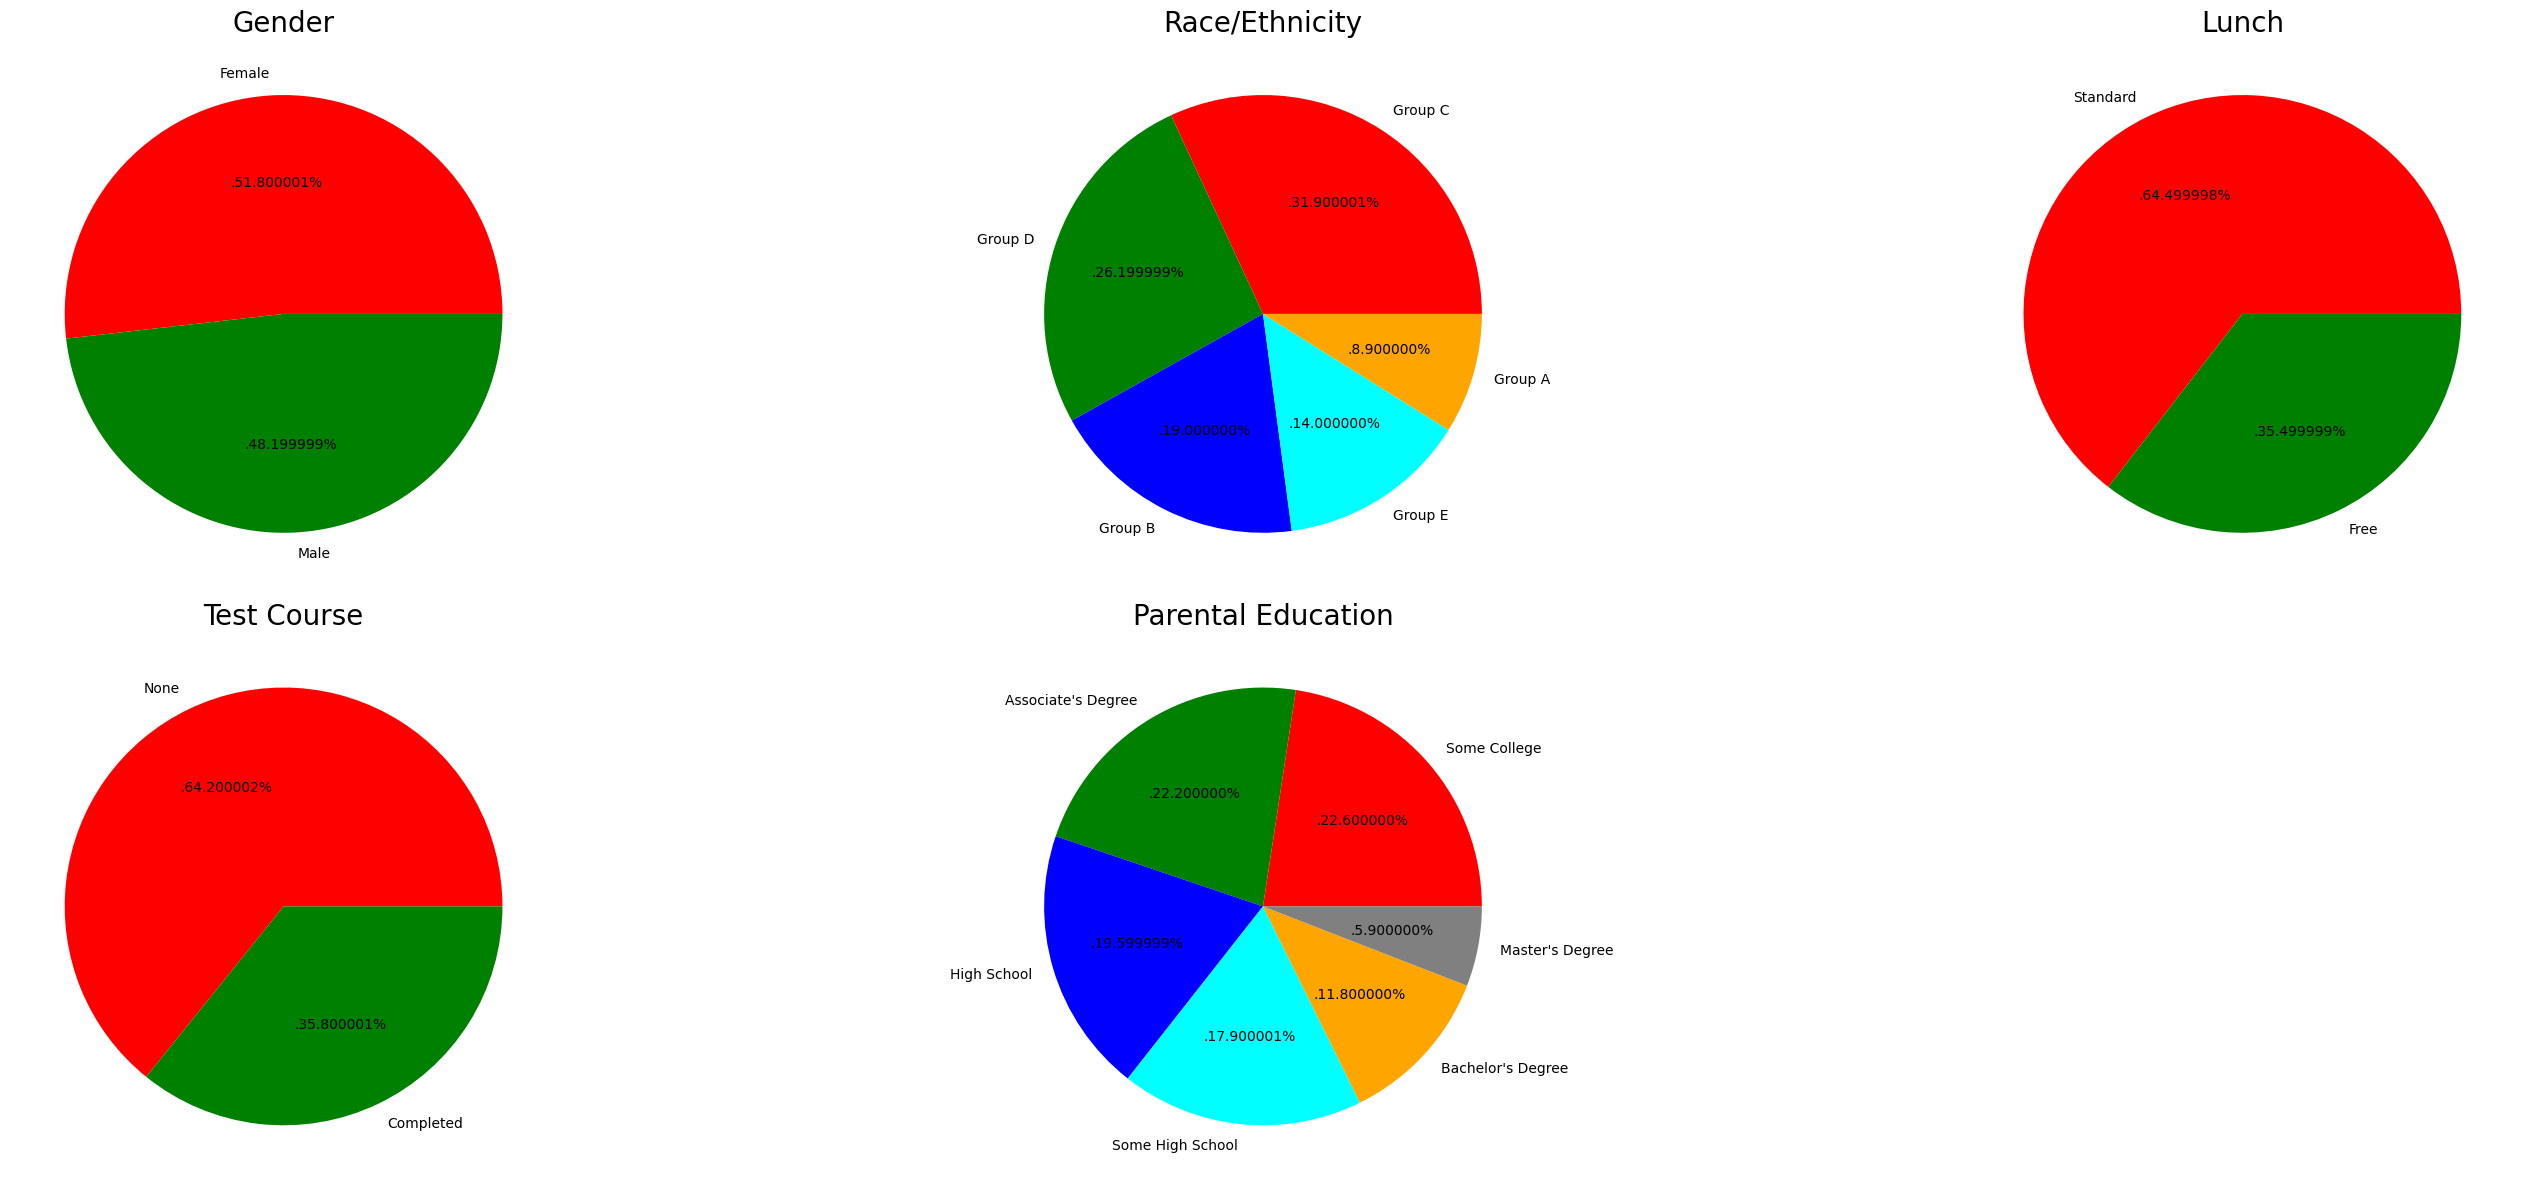

In [38]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(2, 3, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']
plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')

plt.subplot(2, 3, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']
plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')

plt.subplot(2, 3, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']
plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')

plt.subplot(2, 3, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']
plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')

plt.subplot(2, 3, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']
plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')

plt.tight_layout()
plt.show()

Insights

- Number of Male and Female students is almost equal
- Number of Female students is slightly greater than number of Male students
- Number of students are greatest in group C and D
- Number of students is least in group A
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree", with Master's Degree being the least

#### Feature Wise Analysis

#### 4.2 Gender

- Show count plots for gender column
- Visualize students scores distribution with respect to gender to make some conclusion

#### 4.2.1 Count Plot for gender

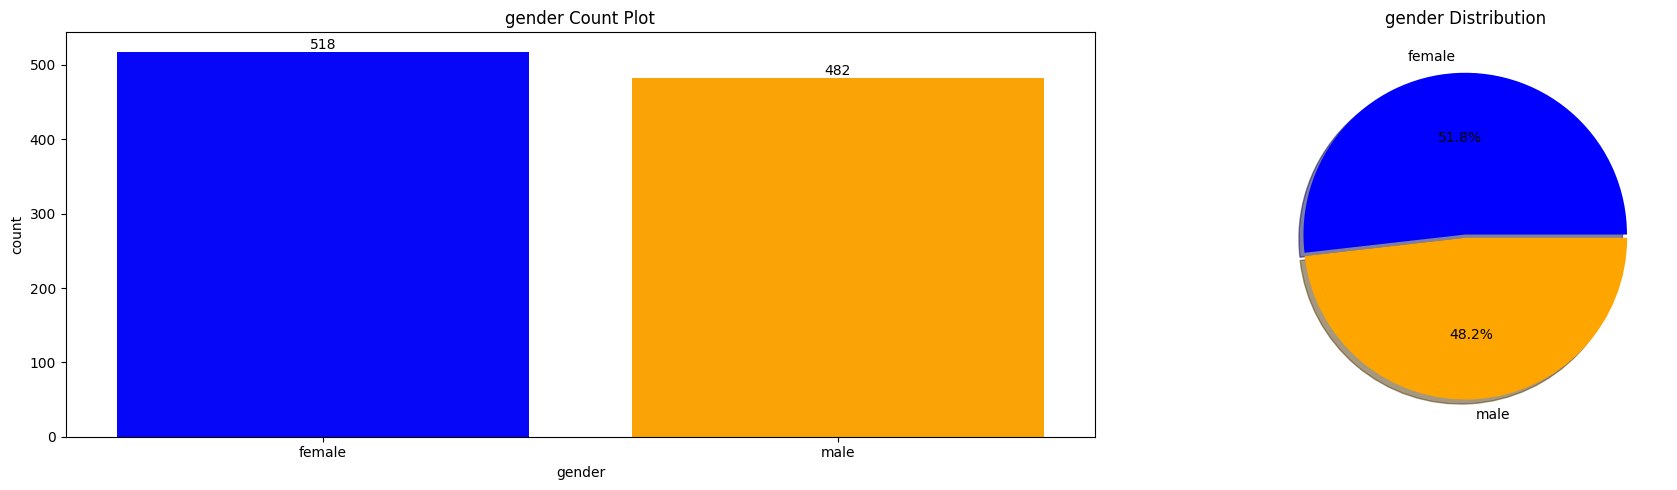

In [43]:
graph = Graph(df)
graph.count_plot('gender')

Insights 

- Gender has balanced data with female students being 518 (52%) and Male students being 482 (48%)

#### 4.2.2 Histogram and Kernel Distribution Function for gender

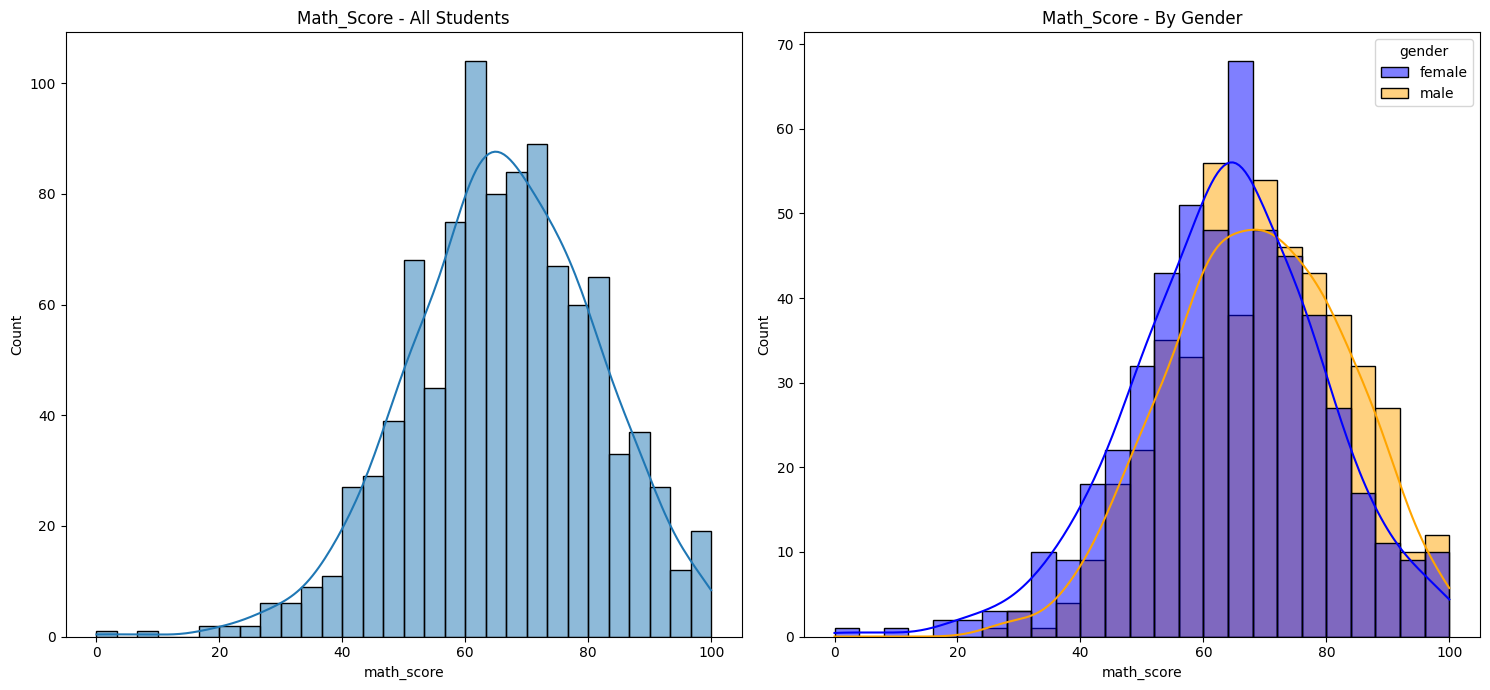

In [18]:
graph.gender_histogram(next_variable('n', 1))

Insights 

- With respect to math_score, male students perform better

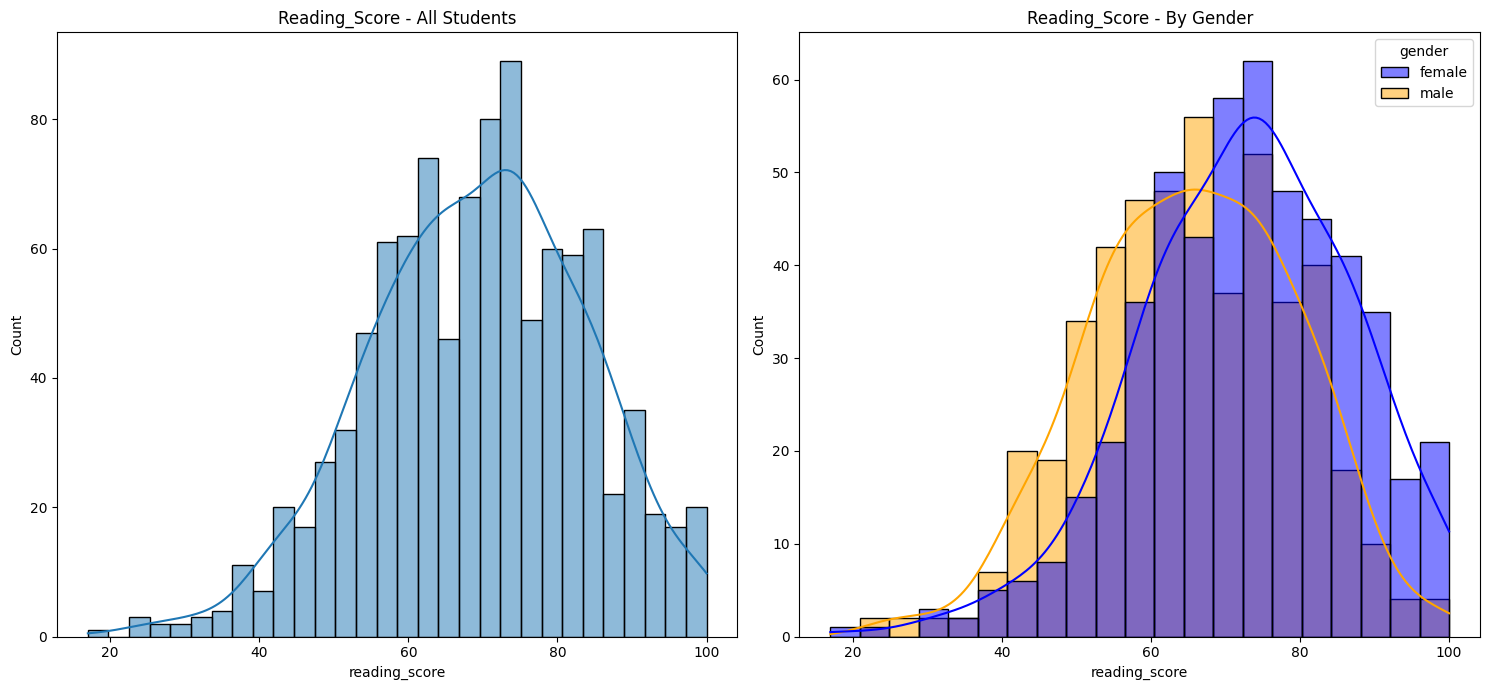

In [19]:
graph.gender_histogram(next_variable("n"))

Insights 

- With respect to reading_score, female students perform better


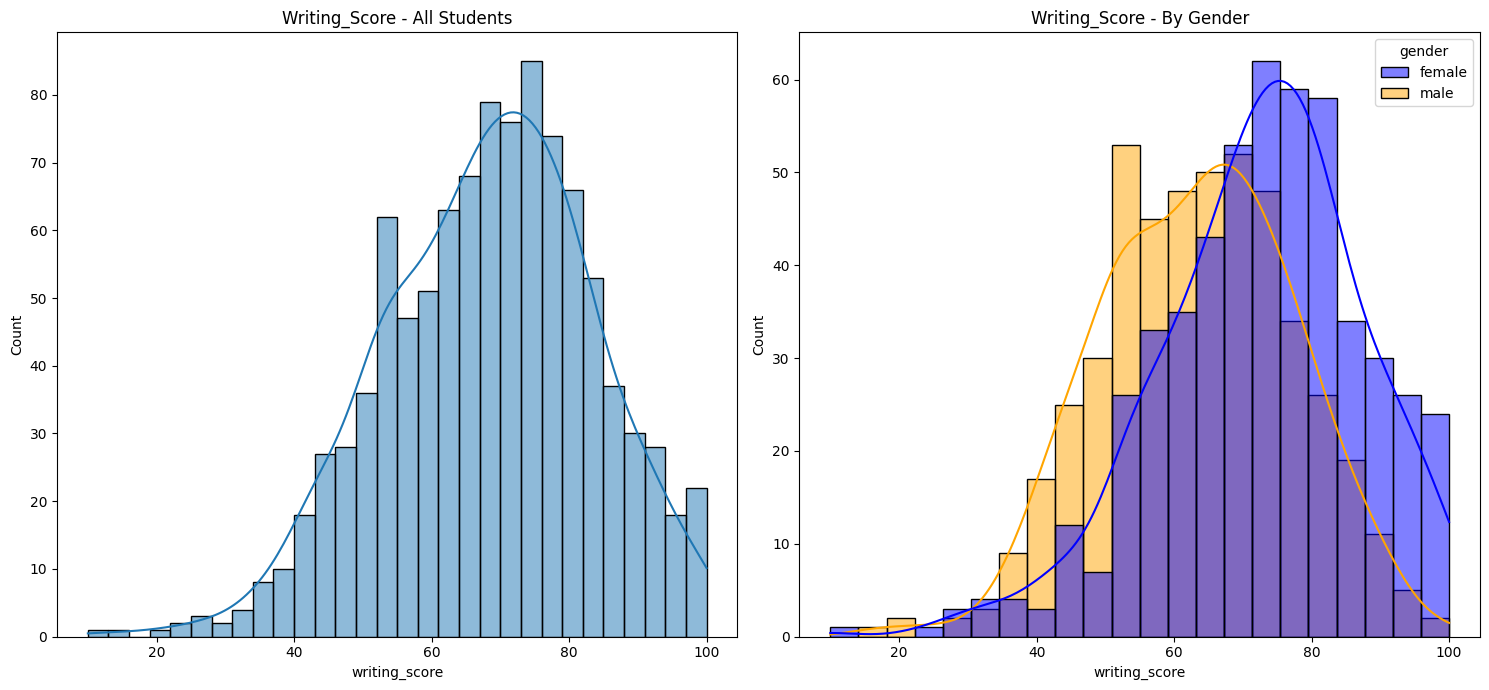

In [20]:
graph.gender_histogram(next_variable("n"))

Insights 

- With respect to writing_score, female students perform better

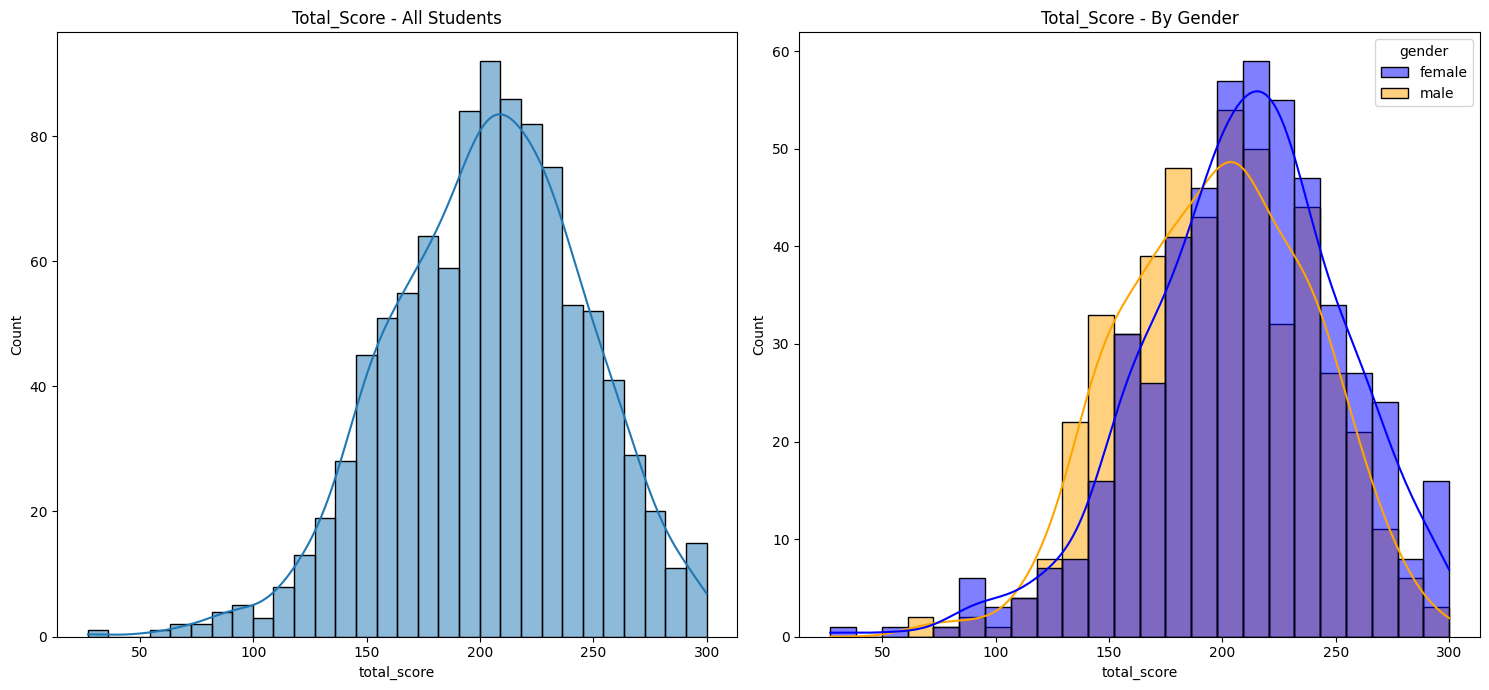

In [21]:
graph.gender_histogram(next_variable("n"))

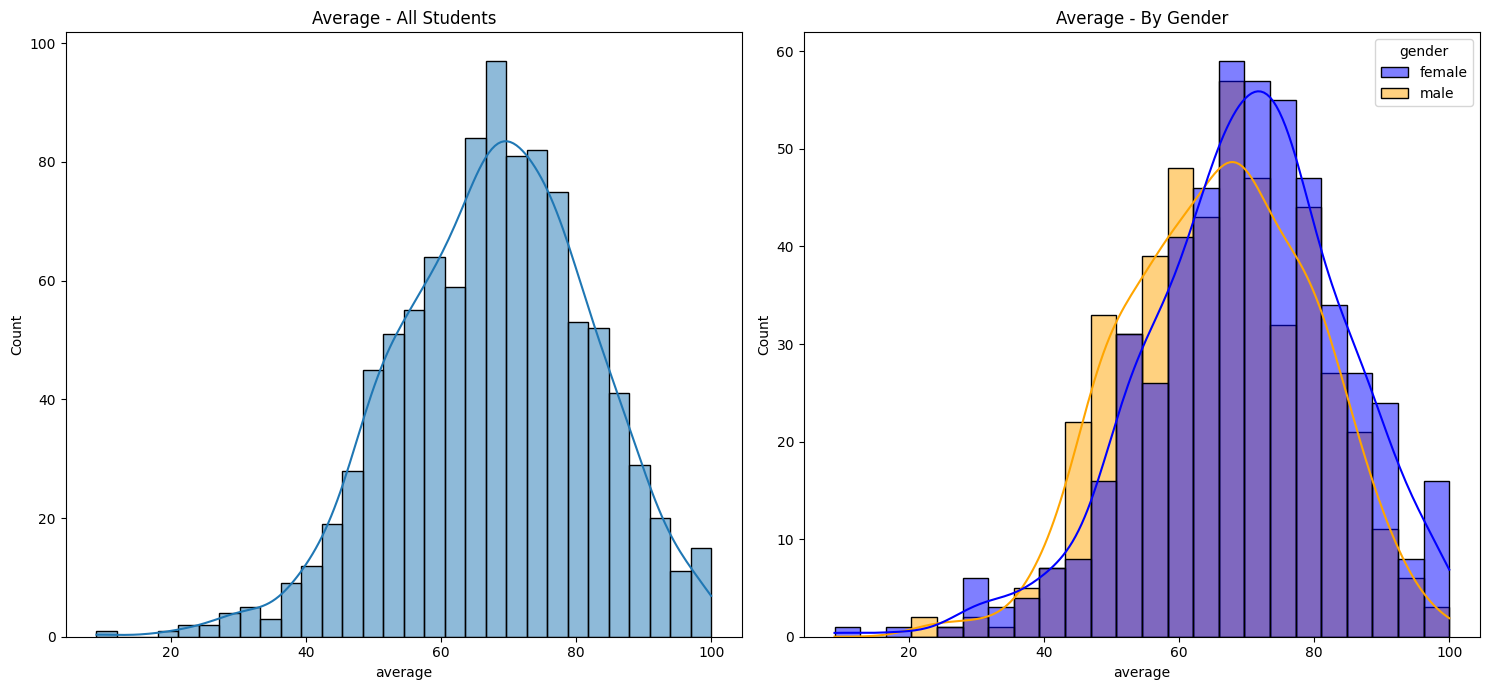

In [22]:
graph.gender_histogram(next_variable("n"))

#### 4.2.3 Bar Chart for Gender 

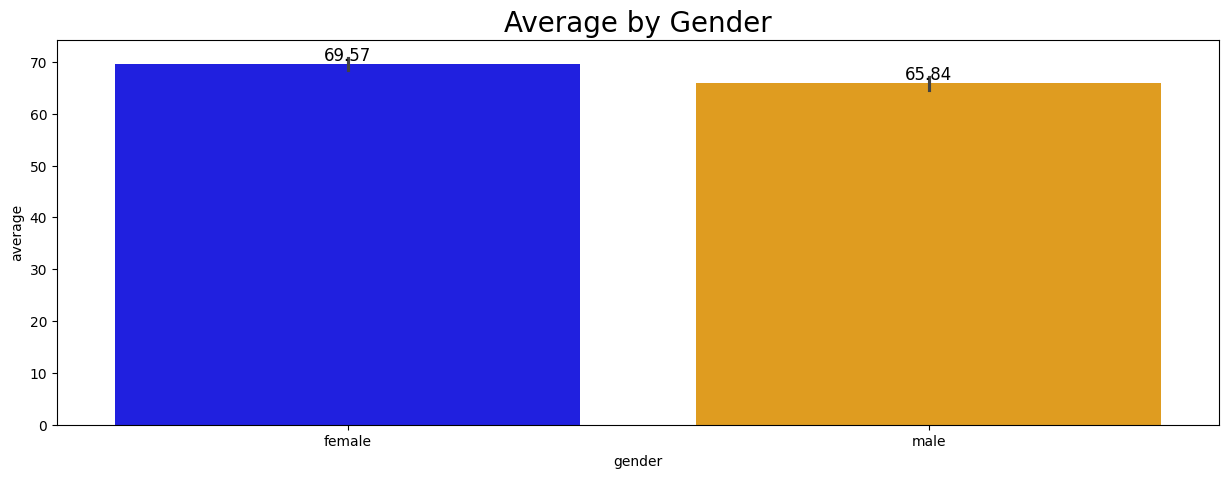

In [24]:
graph.bar_chart(vars.categorical_var[0]) # bar for comparing gender to average

Insights

**So in general, female students perform much better in reading and writing than male students, and although male students perform best in math, there is no much gap between the scores of male and female in math, whereas in reading and wrriting there is a much wider gap.**

In [54]:
var = next_variable('c', 1)
var

'gender'

In [55]:
var = next_variable('c', 0)
var

'race_ethnicity'

#### 4.3 Race Ethnicity

#### 4.3.1 Count Plot for race_ethnicity

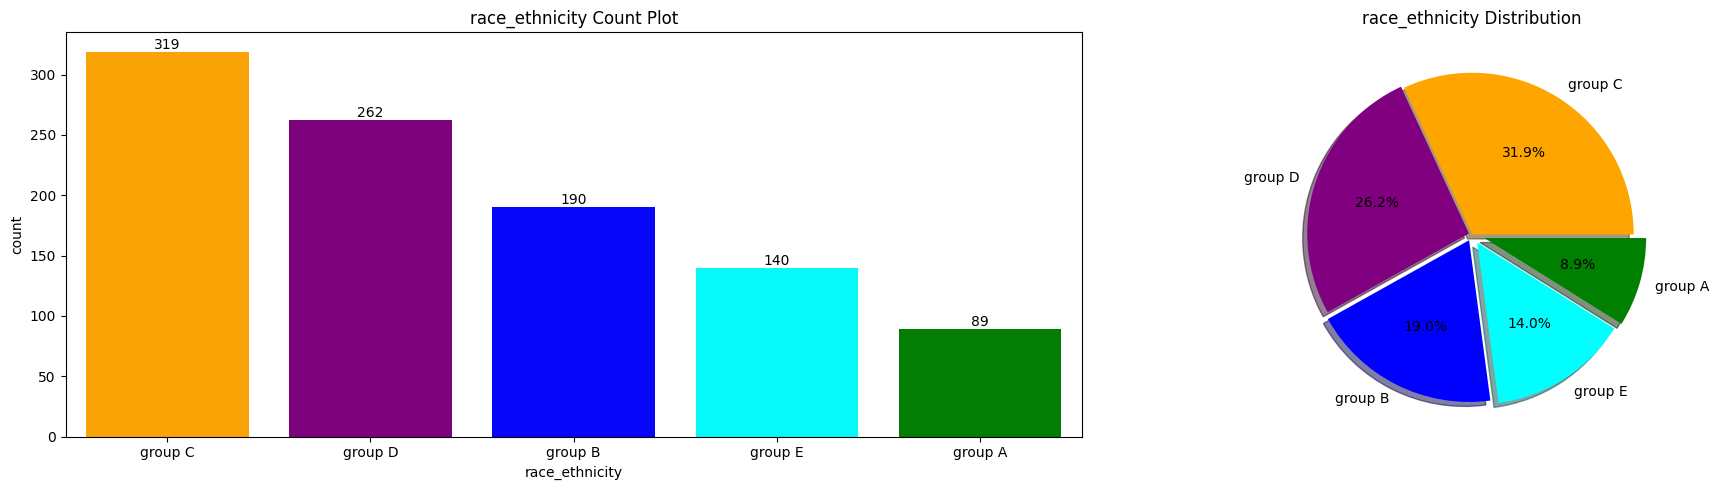

In [56]:
graph.count_plot(var)

Insights

- Group C and D are the majority
- Group A is the least followed by E and then B

#### 4.3.2 Histogram and Kernel Distribution Function for race_ethnicity

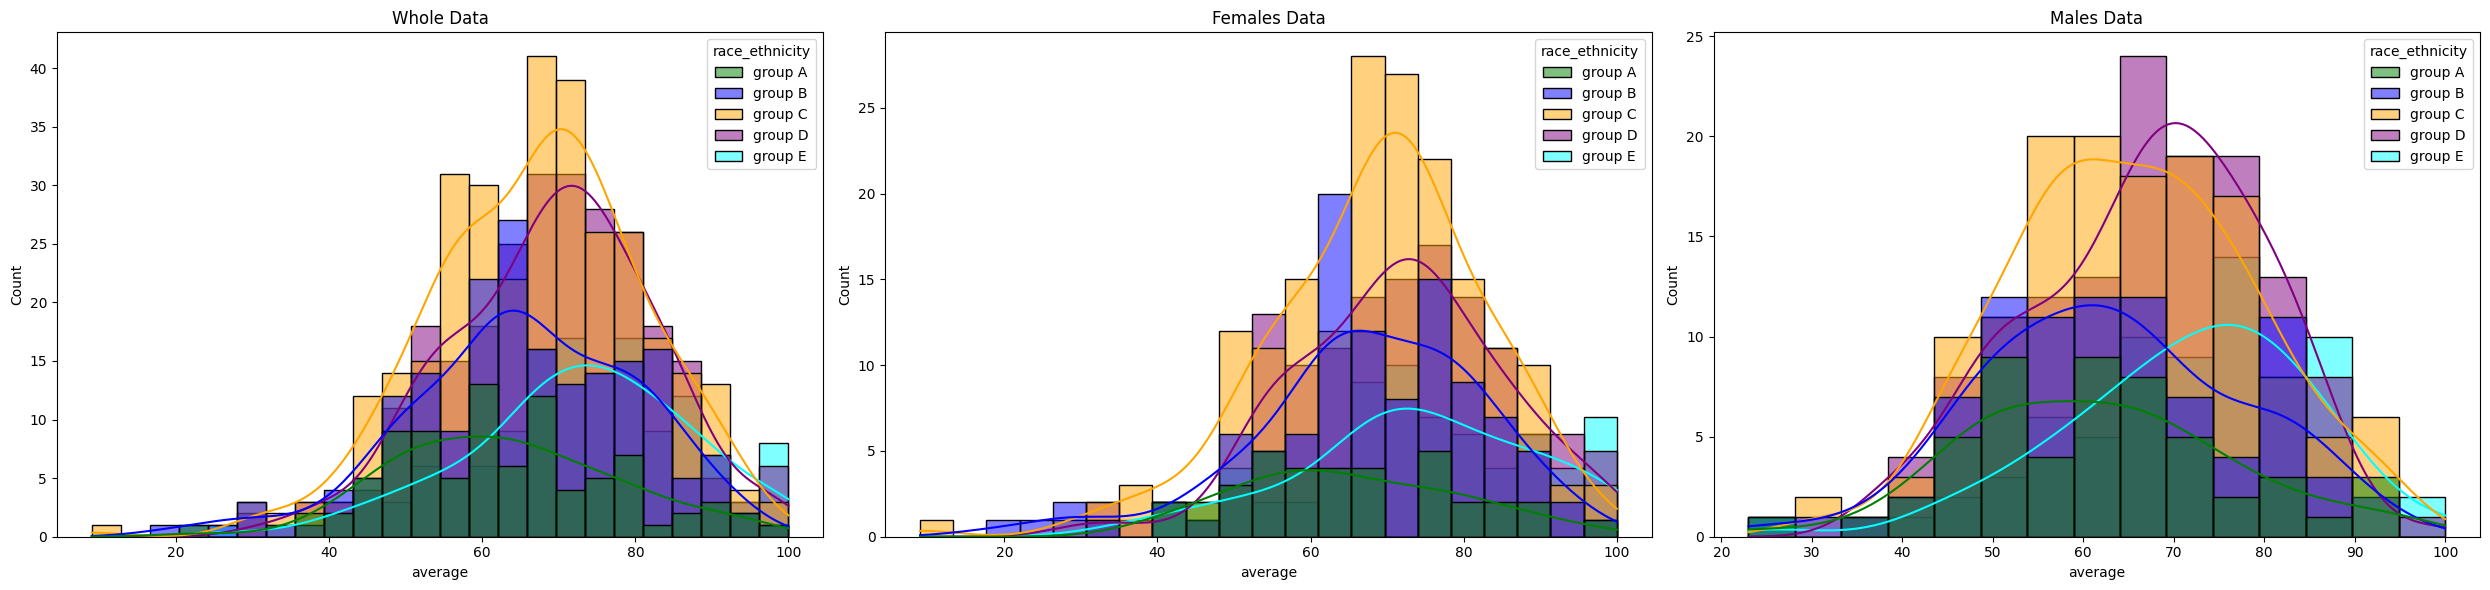

In [57]:
graph.histogram(var)

Insights 

- Group A & B students tend to perform poorly in exams
- Group C & D students tend to perform well in exams

#### 4.3.3 Bar Chart for Race_ethnicity

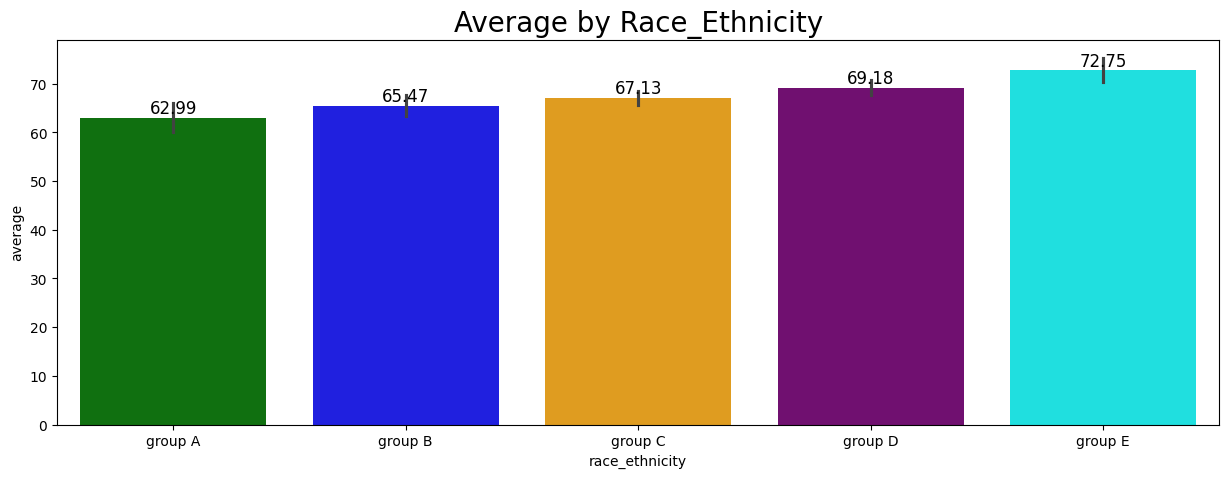

In [58]:
graph.bar_chart(var)

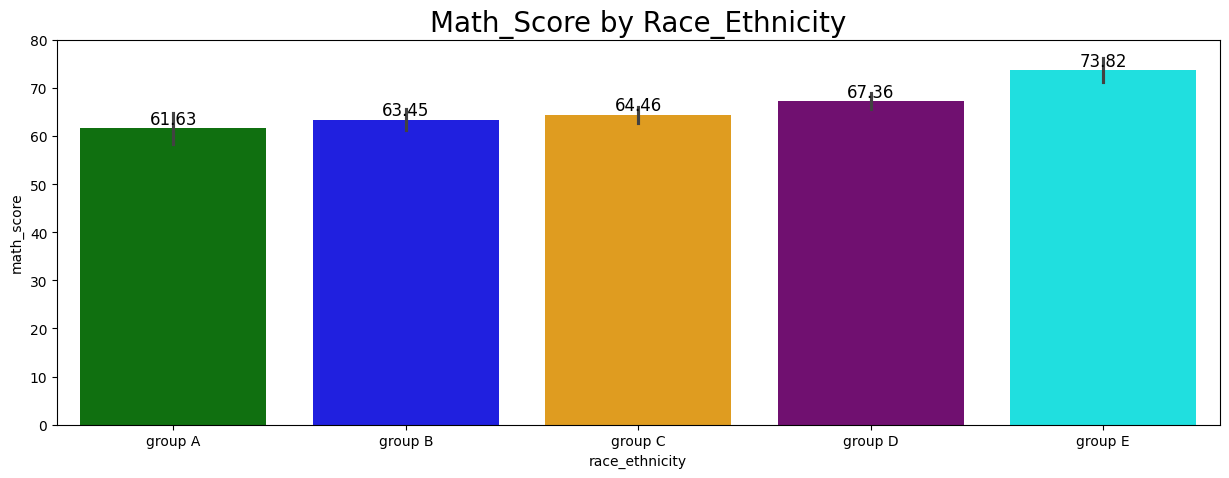

In [59]:
graph.bar_chart(var, 'math_score')

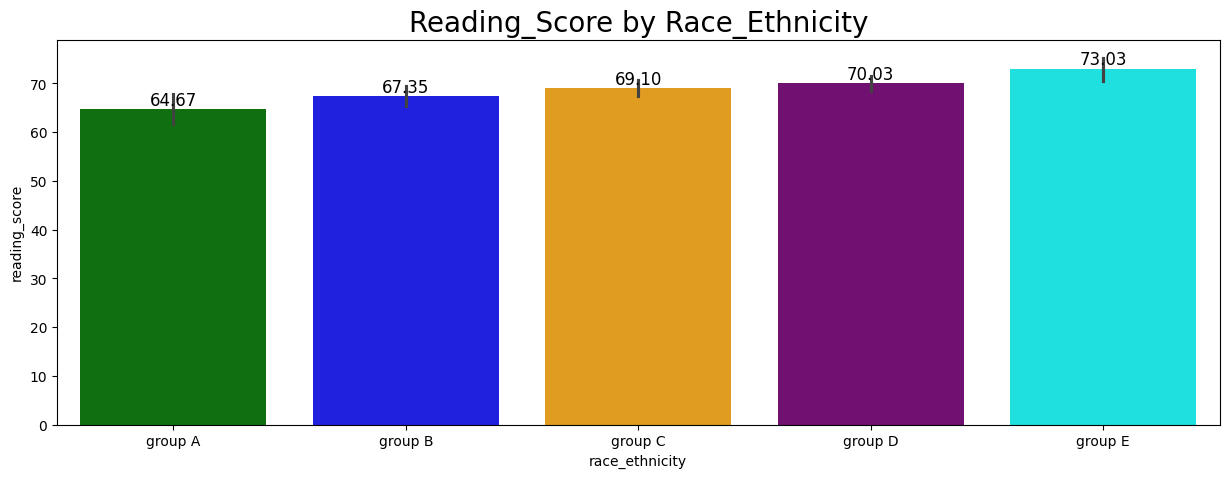

In [60]:
graph.bar_chart(var, "reading_score")

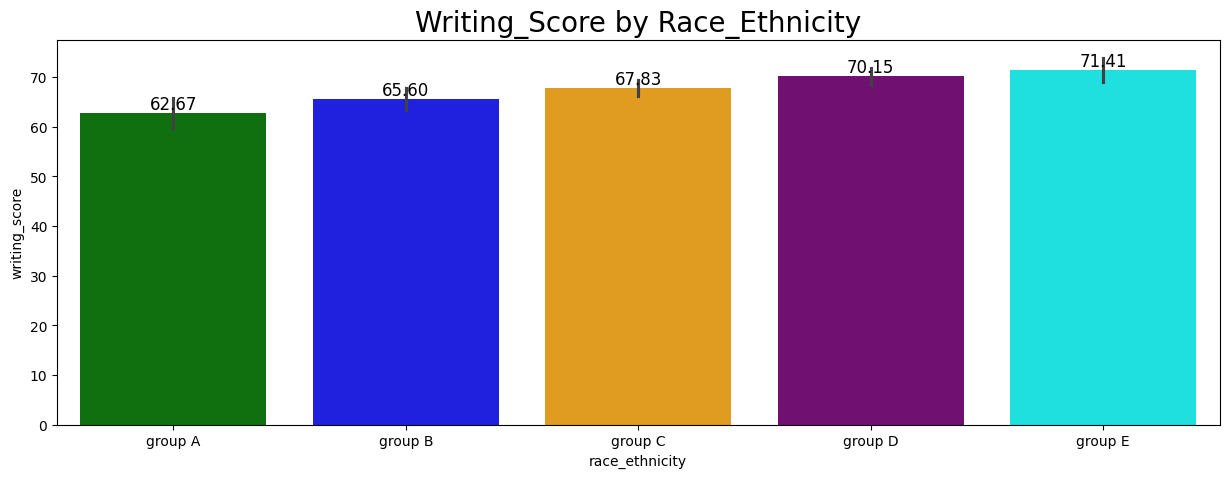

In [61]:
graph.bar_chart(var, "writing_score")

Insights

- Group A students perform the least in exams
- Group B students do not perform well in exams
- Group E students perform well in exams
- Group C & D also perform well in exams


**Students from lowest socio-economic status have a lower avg in all course subjects**

In [62]:
var = next_variable("c")
var

'parental_level_of_education'

#### 4.4.1 Count Plot for parental level of education

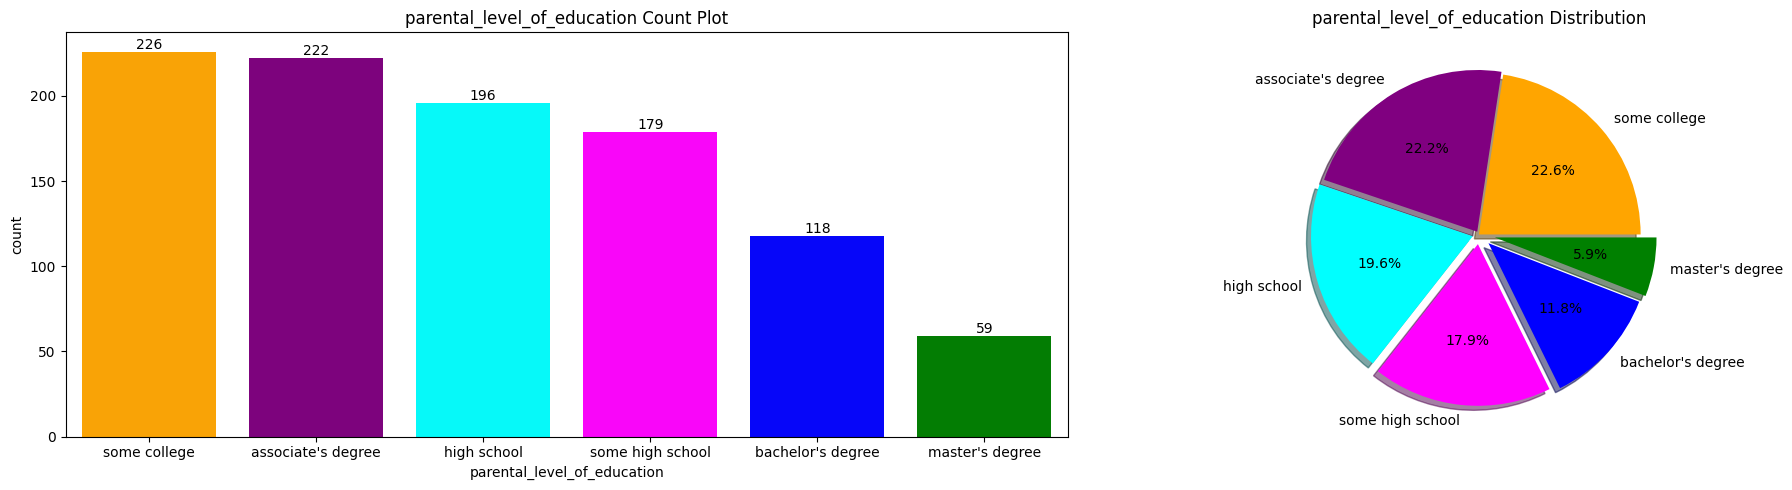

In [63]:
graph.count_plot(var)

#### Insights 
- Largest number of parents are from some college and associate's degree.
- Least number of parents are from master's degree

#### 4.4.2 Histogram for parental level of education

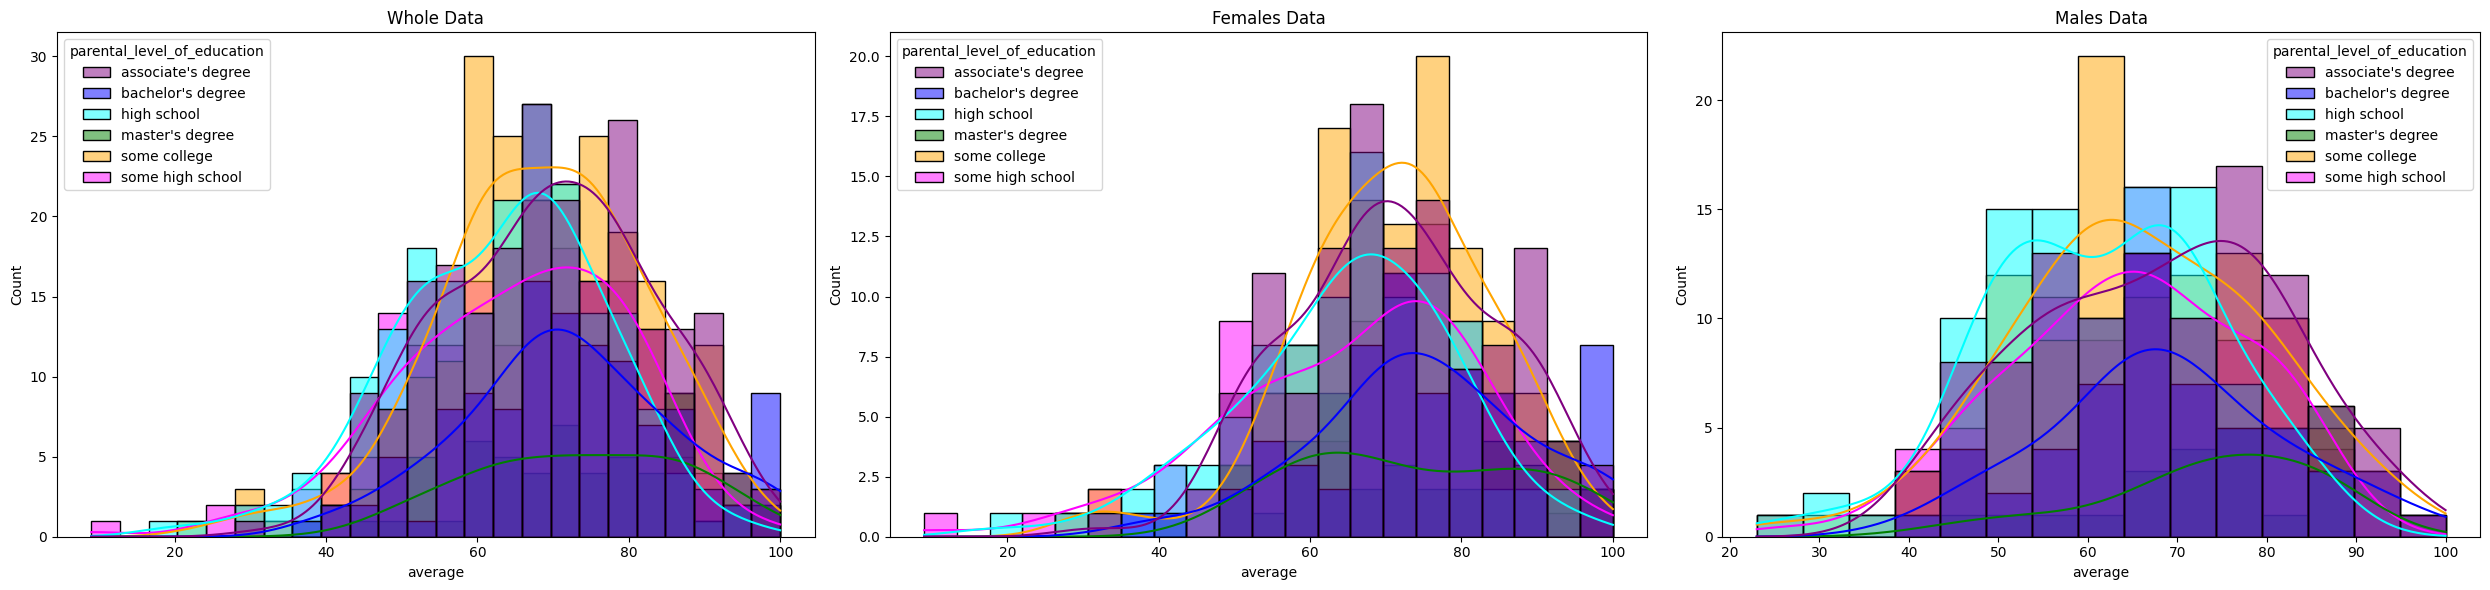

In [64]:
graph.histogram(var)

#### 4.4.3 Bar Chart for parental level of education

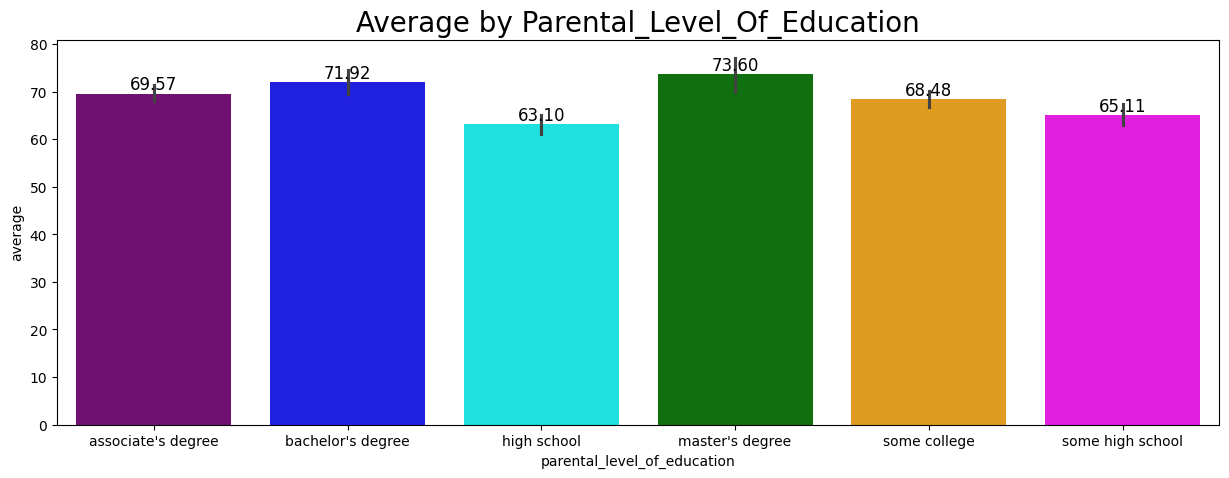

In [65]:
graph.bar_chart(var)

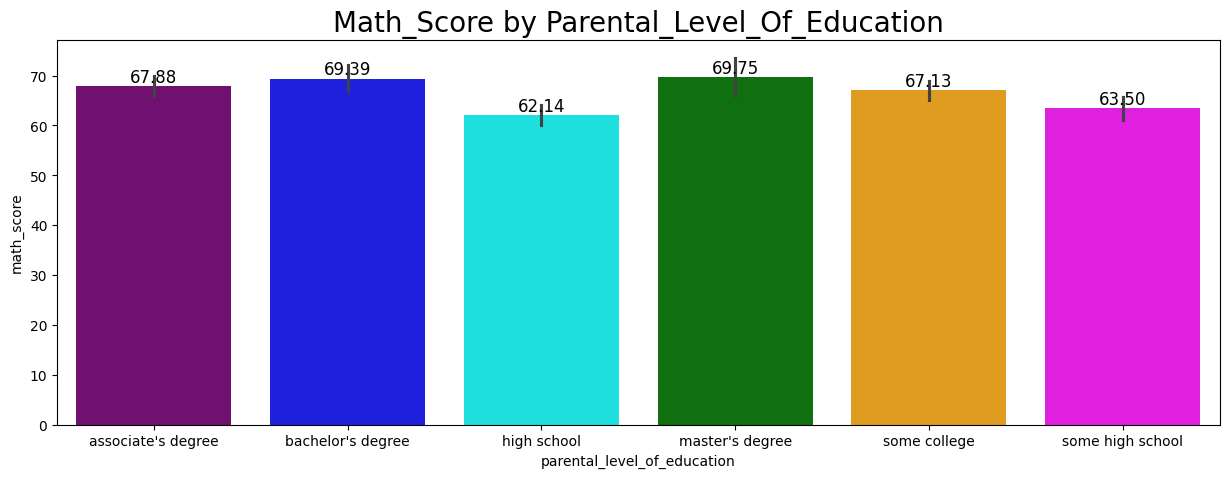

In [66]:
graph.bar_chart(var, vars.numerical_var[0])

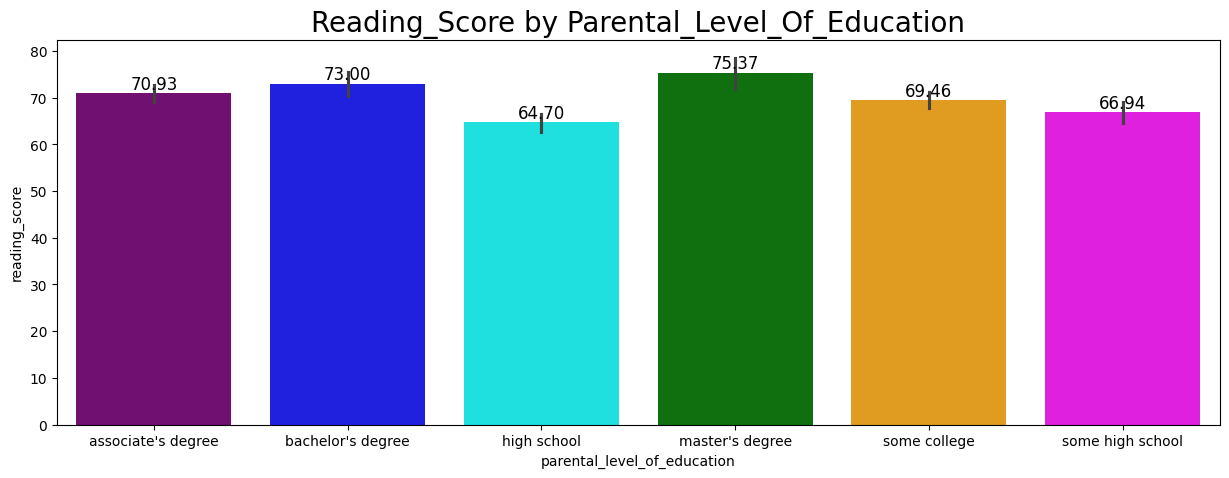

In [67]:
graph.bar_chart(var, vars.numerical_var[1])

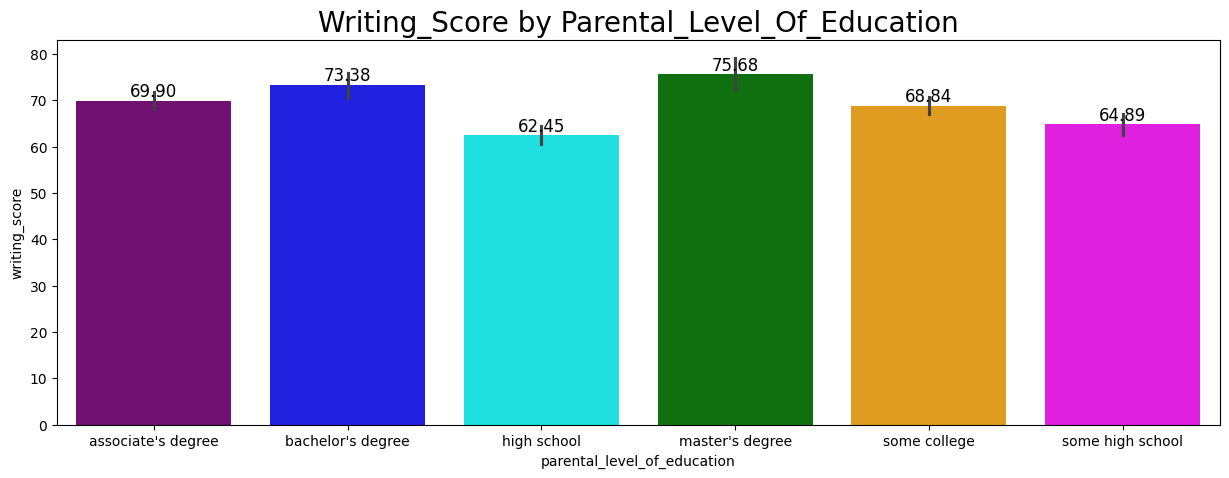

In [68]:
graph.bar_chart(var, vars.numerical_var[2])

#### Insights 
- The score of student whose parents possess master and bachelor level education are higher than others.
- Students whose parents have only high school or some high school education tend to perform poorly in exams

In [69]:
var = next_variable('c')

In [70]:
print(var)

lunch


#### 4.5.1 Count Plot for lunch

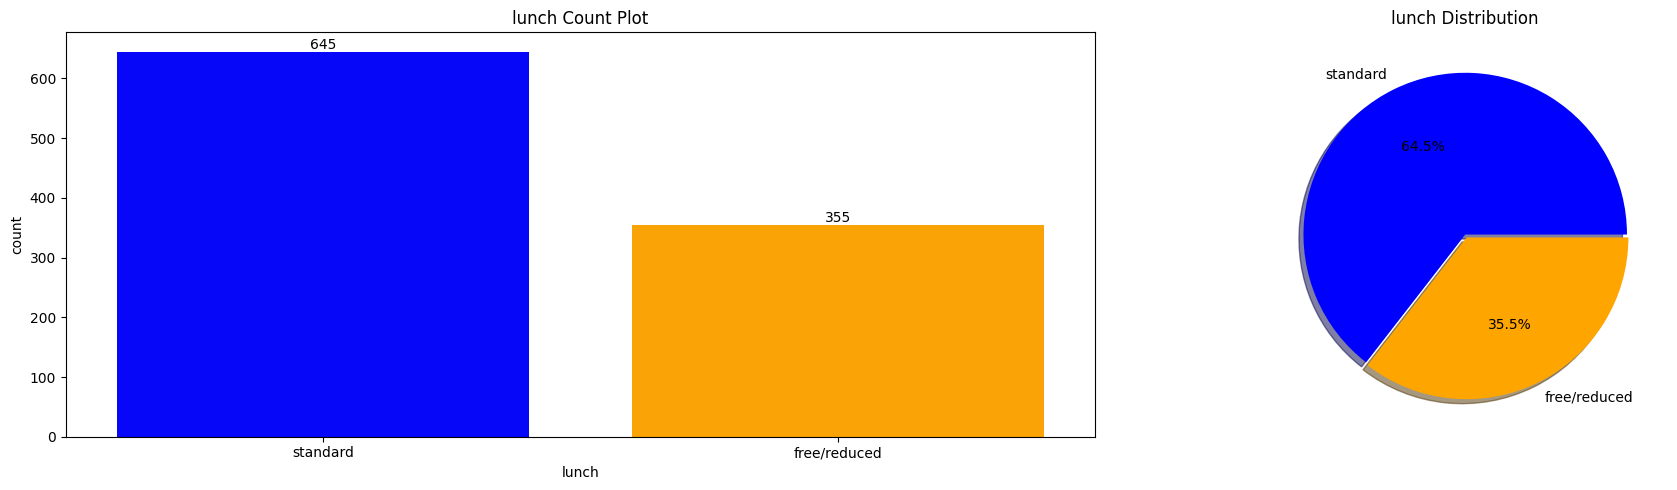

In [71]:
graph.count_plot(var)

Insights

- Approximately 65% of students eat standard food

#### 4.5.2 Histogram for lunch

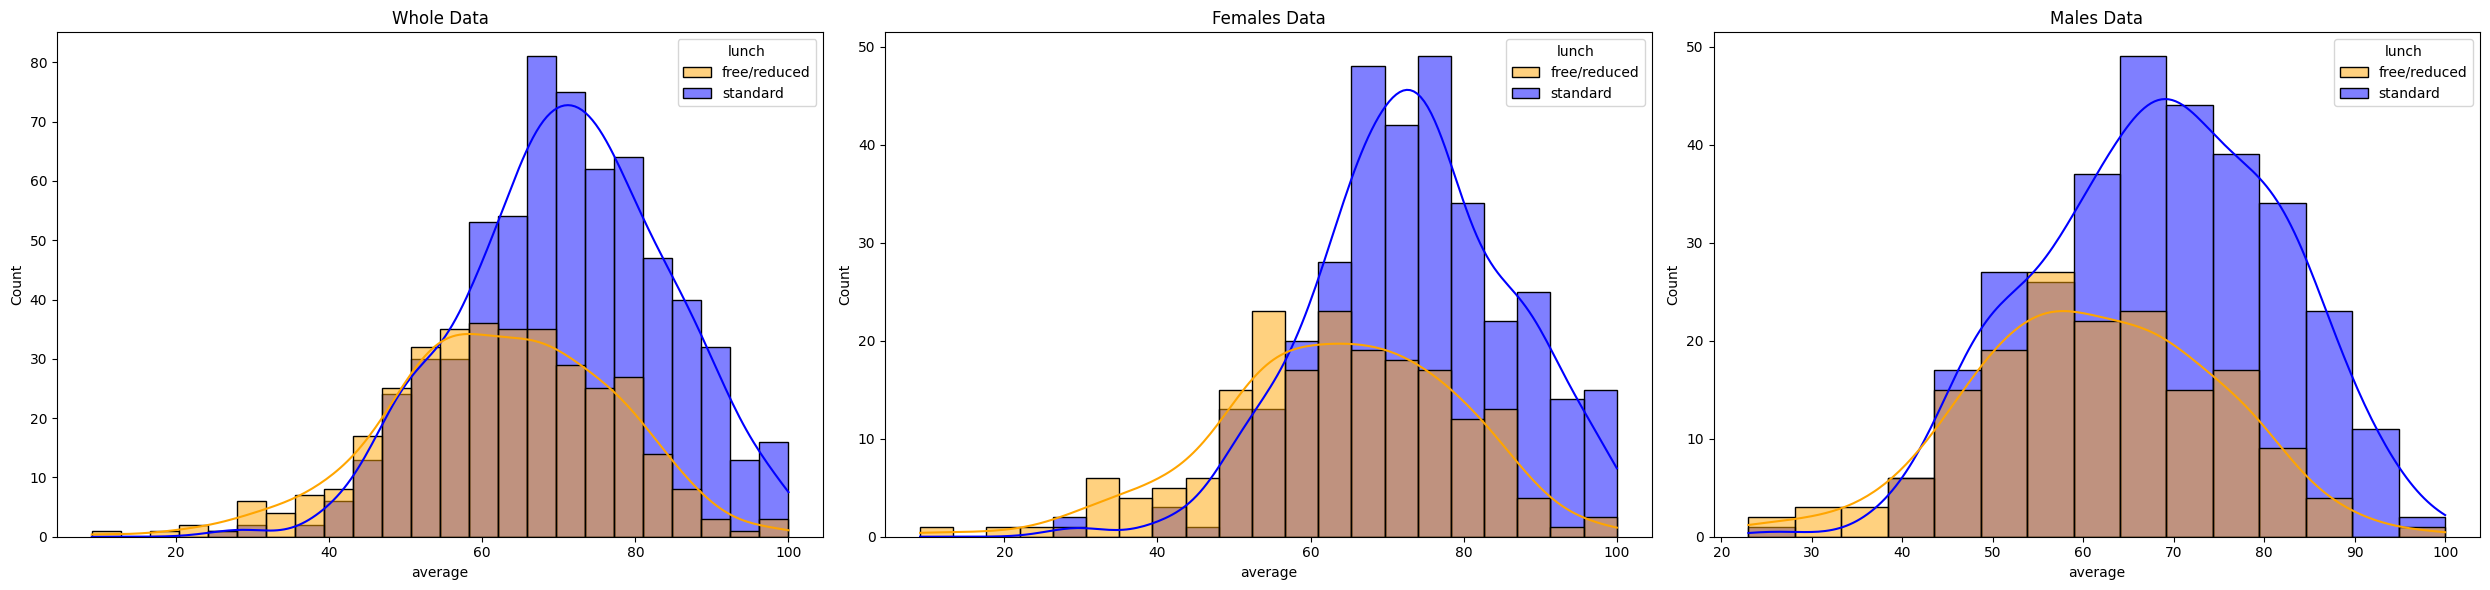

In [72]:
graph.histogram(var)

#### 4.5.3 Bar chart for lunch

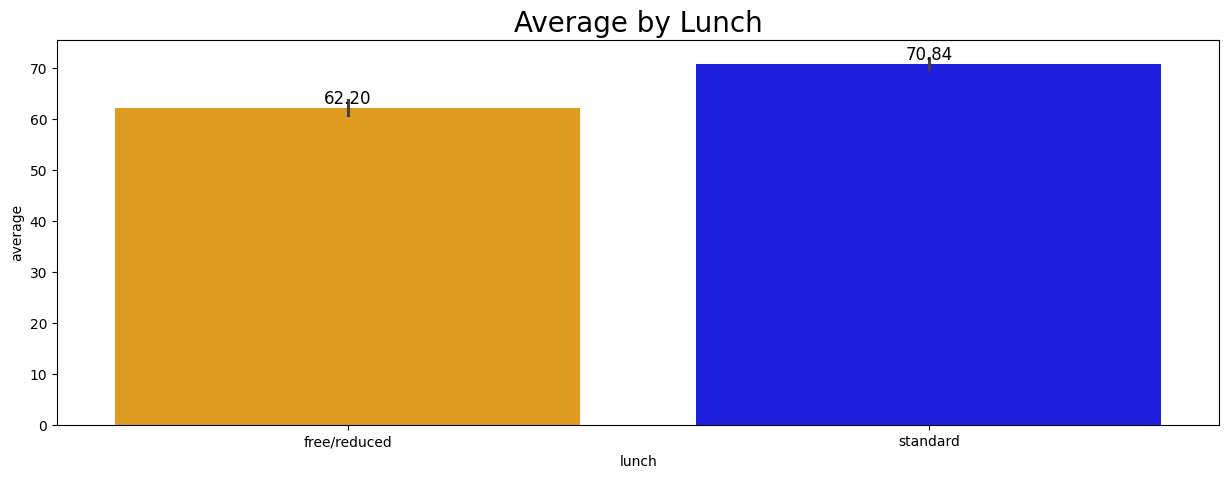

In [73]:
graph.bar_chart(var)

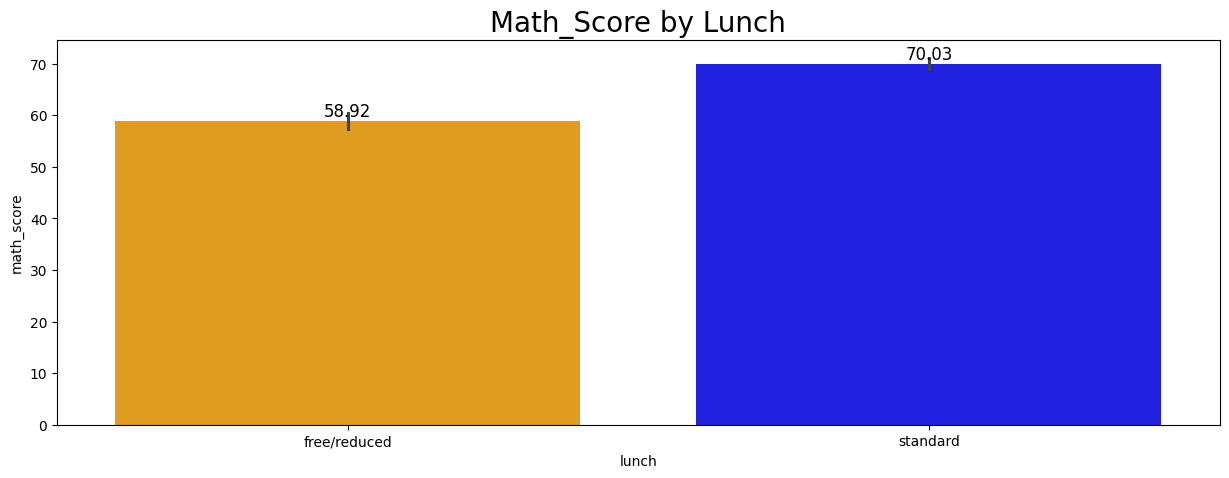

In [74]:
graph.bar_chart(var, vars.numerical_var[0])

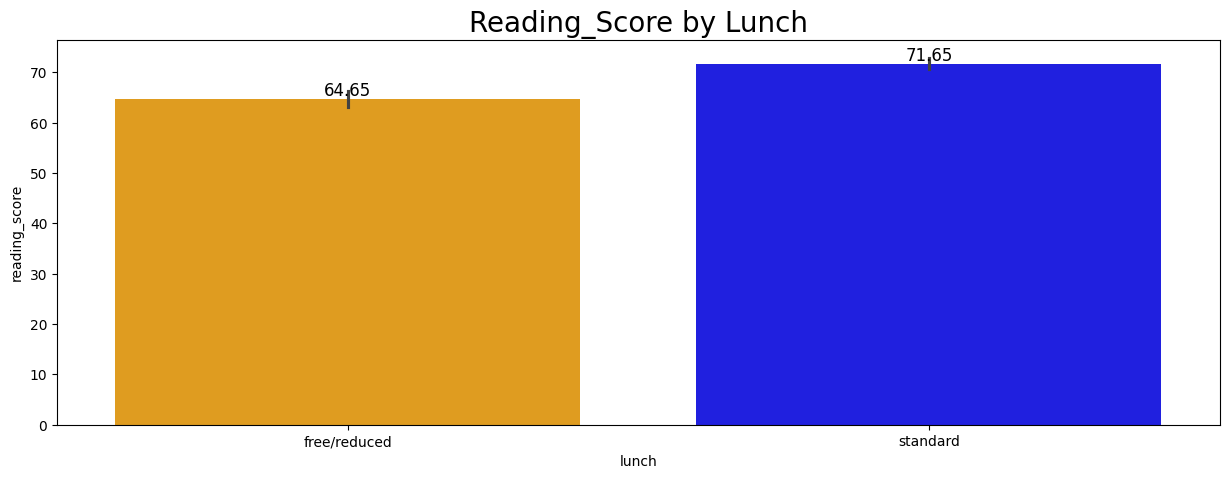

In [75]:
graph.bar_chart(var, vars.numerical_var[1])

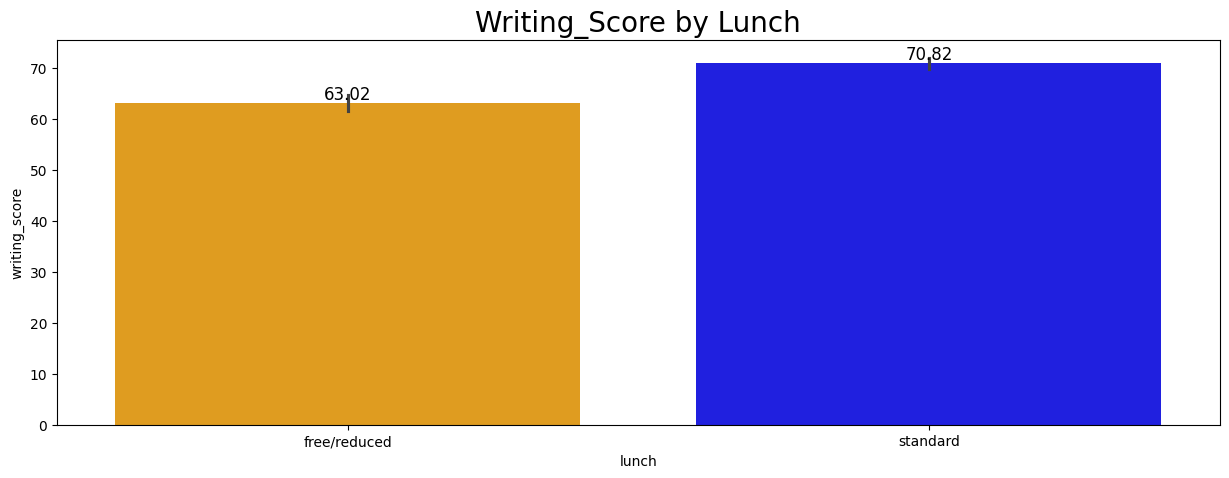

In [76]:
graph.bar_chart(var, vars.numerical_var[2])

Insights 

- Standard lunch helps students to perform well in exams.
- Standard lunch helps students perform well in exams be it a male or a female

#### 4.5.4 Does lunch help students complete the test preparation course?

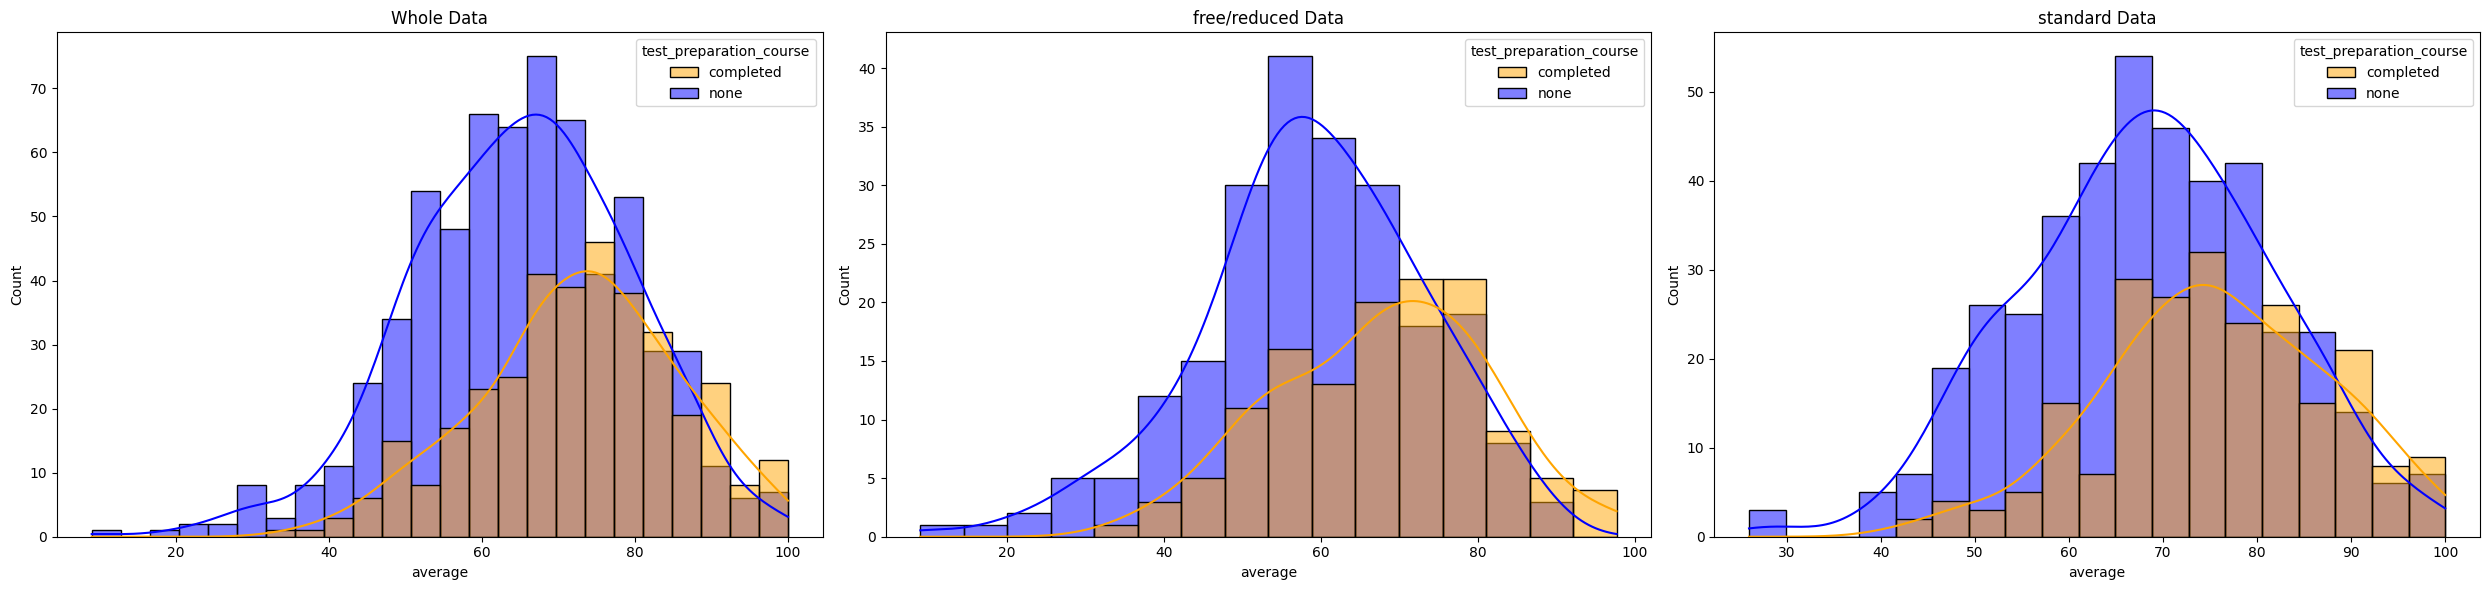

In [45]:
graph.histogram('test_preparation_course', 'lunch', 'free/reduced', 'standard')

Insights 

- There are more students who completed the course in Standard than those in free/reduced
- This suggests that students who take standard lunch are more likely to complete the exam prep course than those who take free/reduced

In [77]:
var = next_variable('c')

In [78]:
print(var)

test_preparation_course


#### 4.6.1 Count Plot for test preparation course

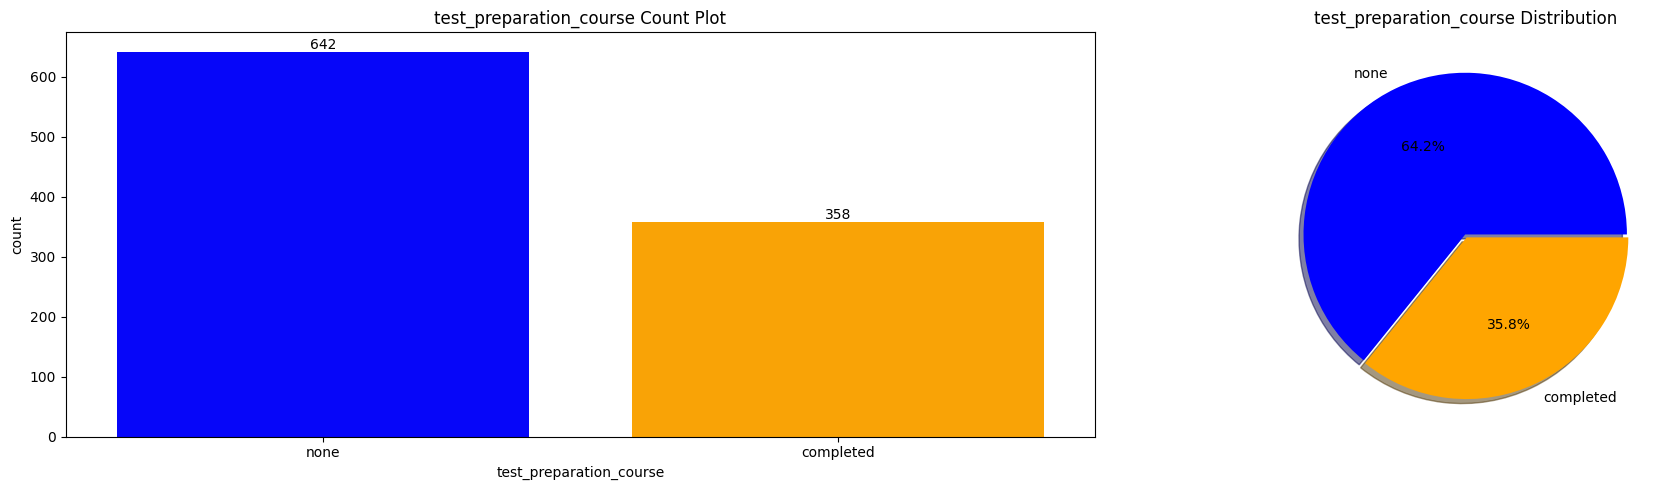

In [79]:
graph.count_plot(var)

Insights 

- Many students complete the test preparation course

#### 4.6.2 Histogram for test preparation course

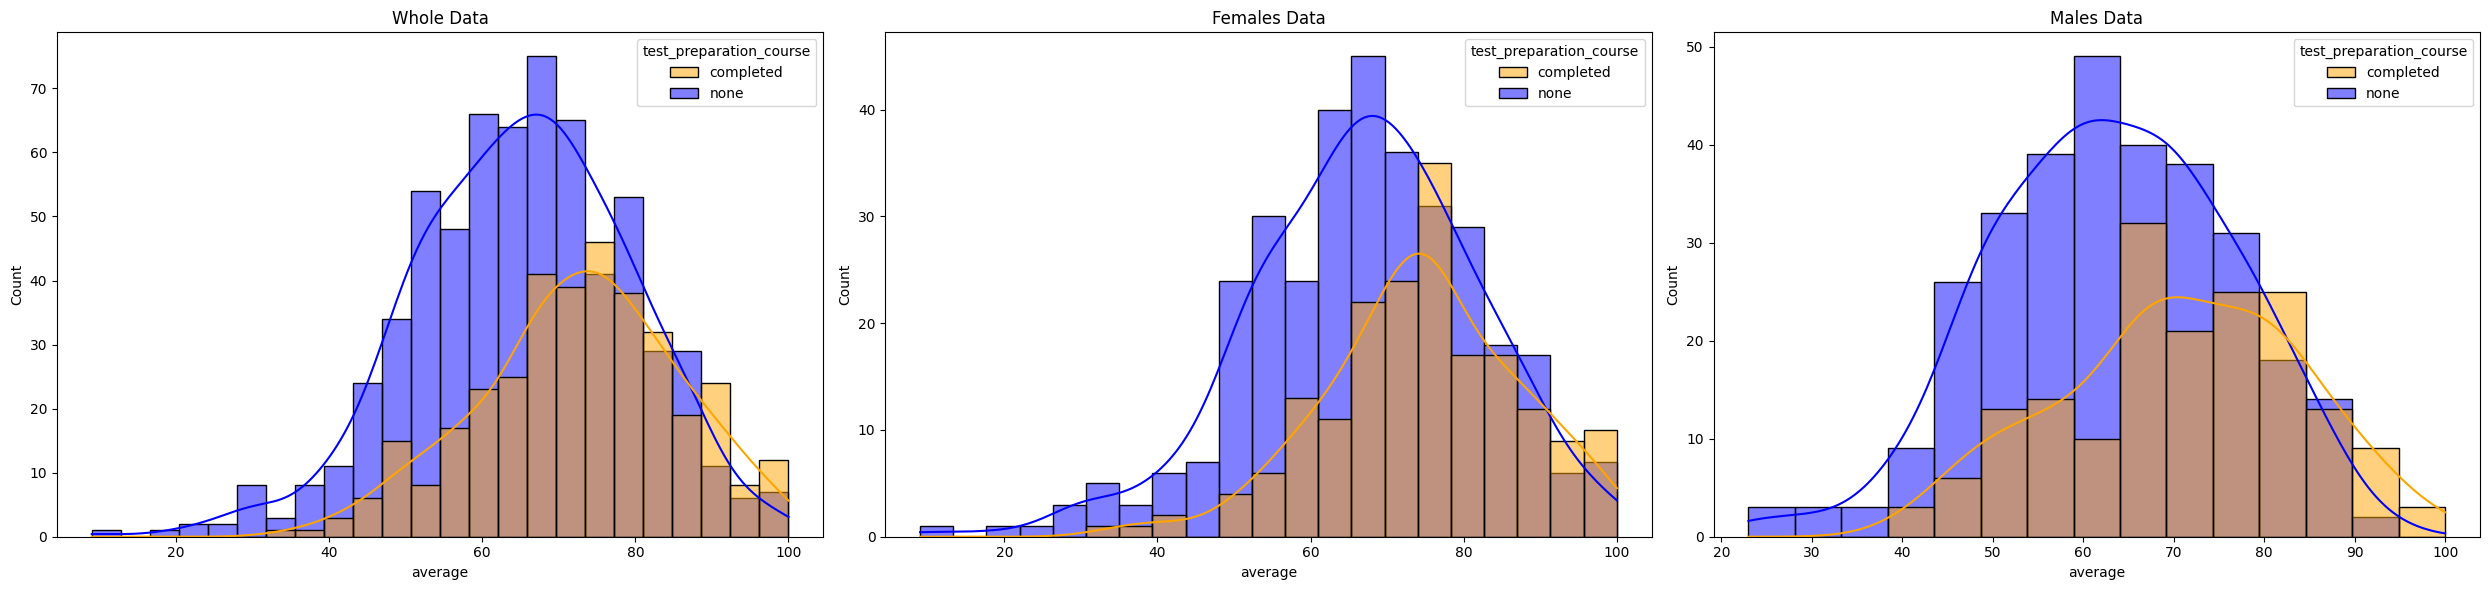

In [80]:
graph.histogram(var)

#### 4.6.3 Bar chart for test preparation course

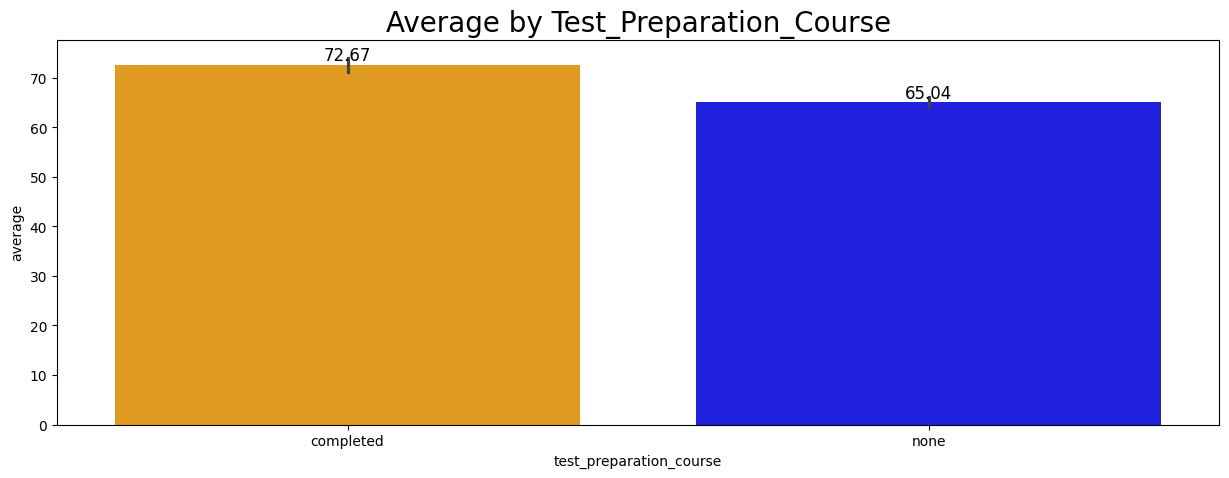

In [81]:
graph.bar_chart(var)

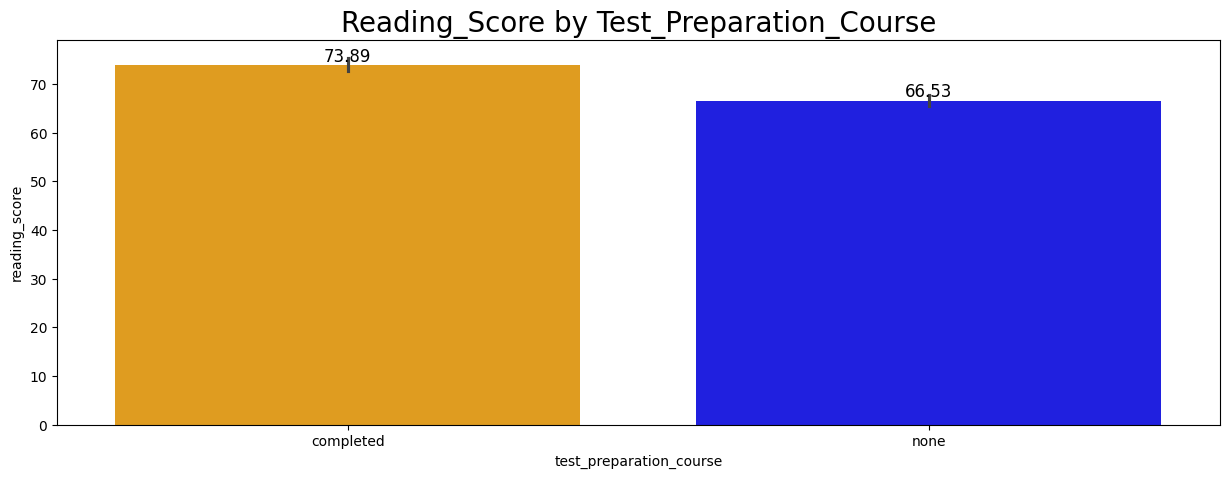

In [82]:
graph.bar_chart(var, 'reading_score')

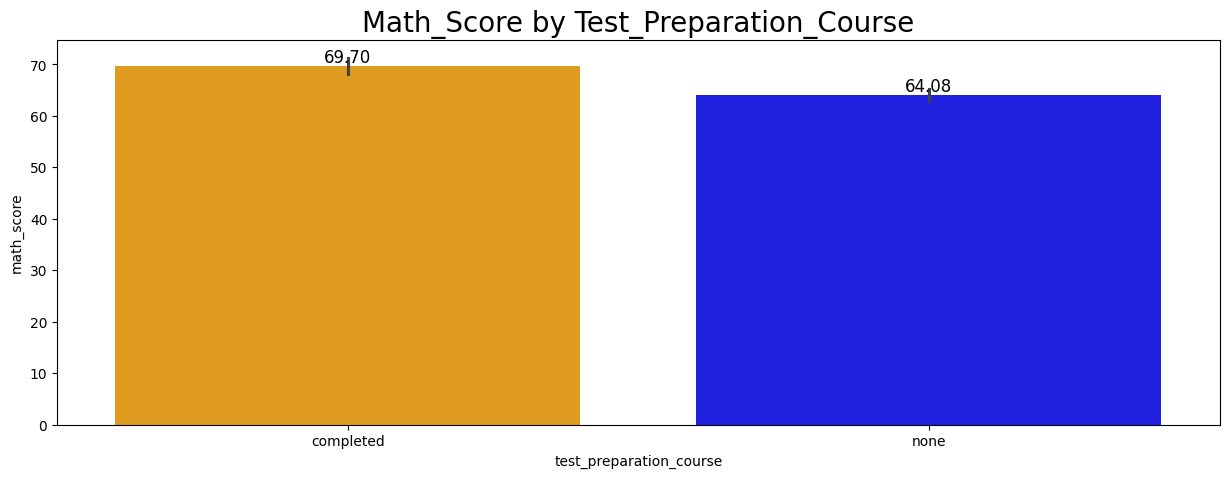

In [83]:
graph.bar_chart(var, "math_score")

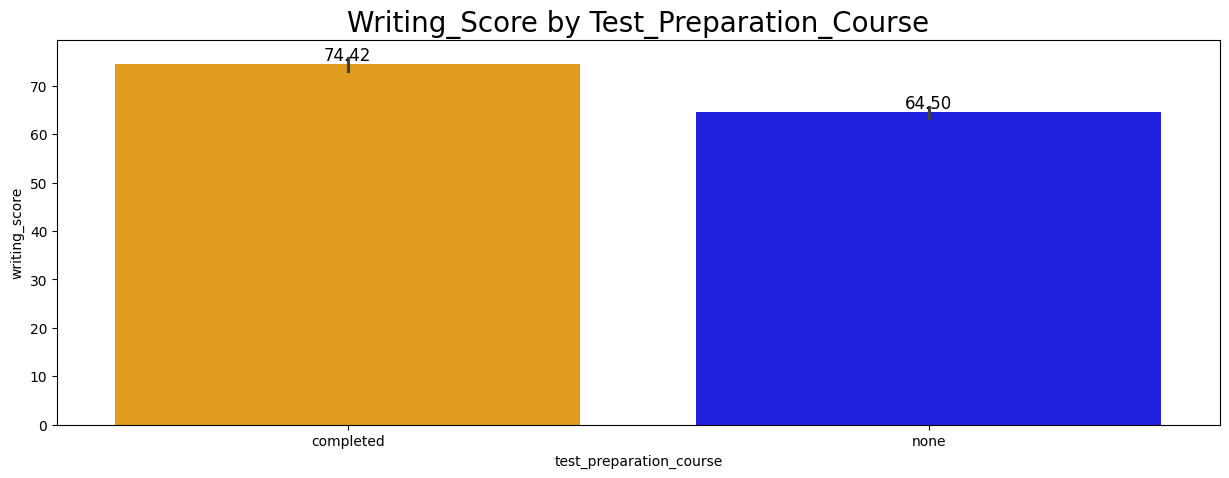

In [84]:
graph.bar_chart(var, 'writing_score')

Insights

- Students who do not complete the test preparation course are more likely to fail
- Students who complete the test preparation course are more likely to pass

#### 4.7 Maximum score of students in all three subjects using violin plots

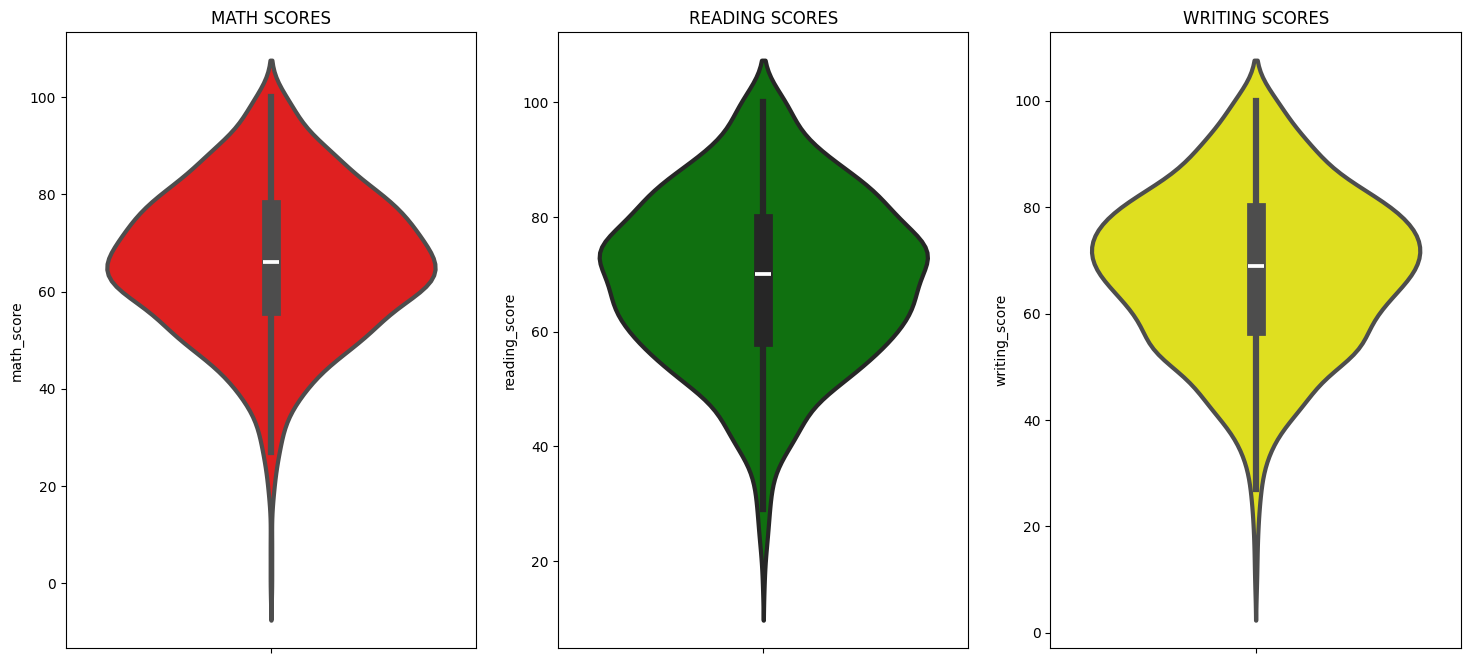

In [85]:
fig, axs = plt.subplots(1, 3, figsize=(18,8))
axs[0].set_title("MATH SCORES")
sns.violinplot(y='math_score', data=df, color='red', linewidth=3, ax=axs[0])
axs[1].set_title('READING SCORES')
sns.violinplot(y='reading_score', data=df, color='green', linewidth=3, ax=axs[1])
axs[2].set_title('WRITING SCORES')
sns.violinplot(y='writing_score', data=df, color='yellow', linewidth=3, ax=axs[2])
plt.show()

Insights

- From the above three plots its clearly visible that most of the students score in between 60 - 80 in Maths whereas in reading and writing most of them score from 50 -85

#### 4.8 CHECKING OUTLIERS

In [86]:
graph  = Graph(df)

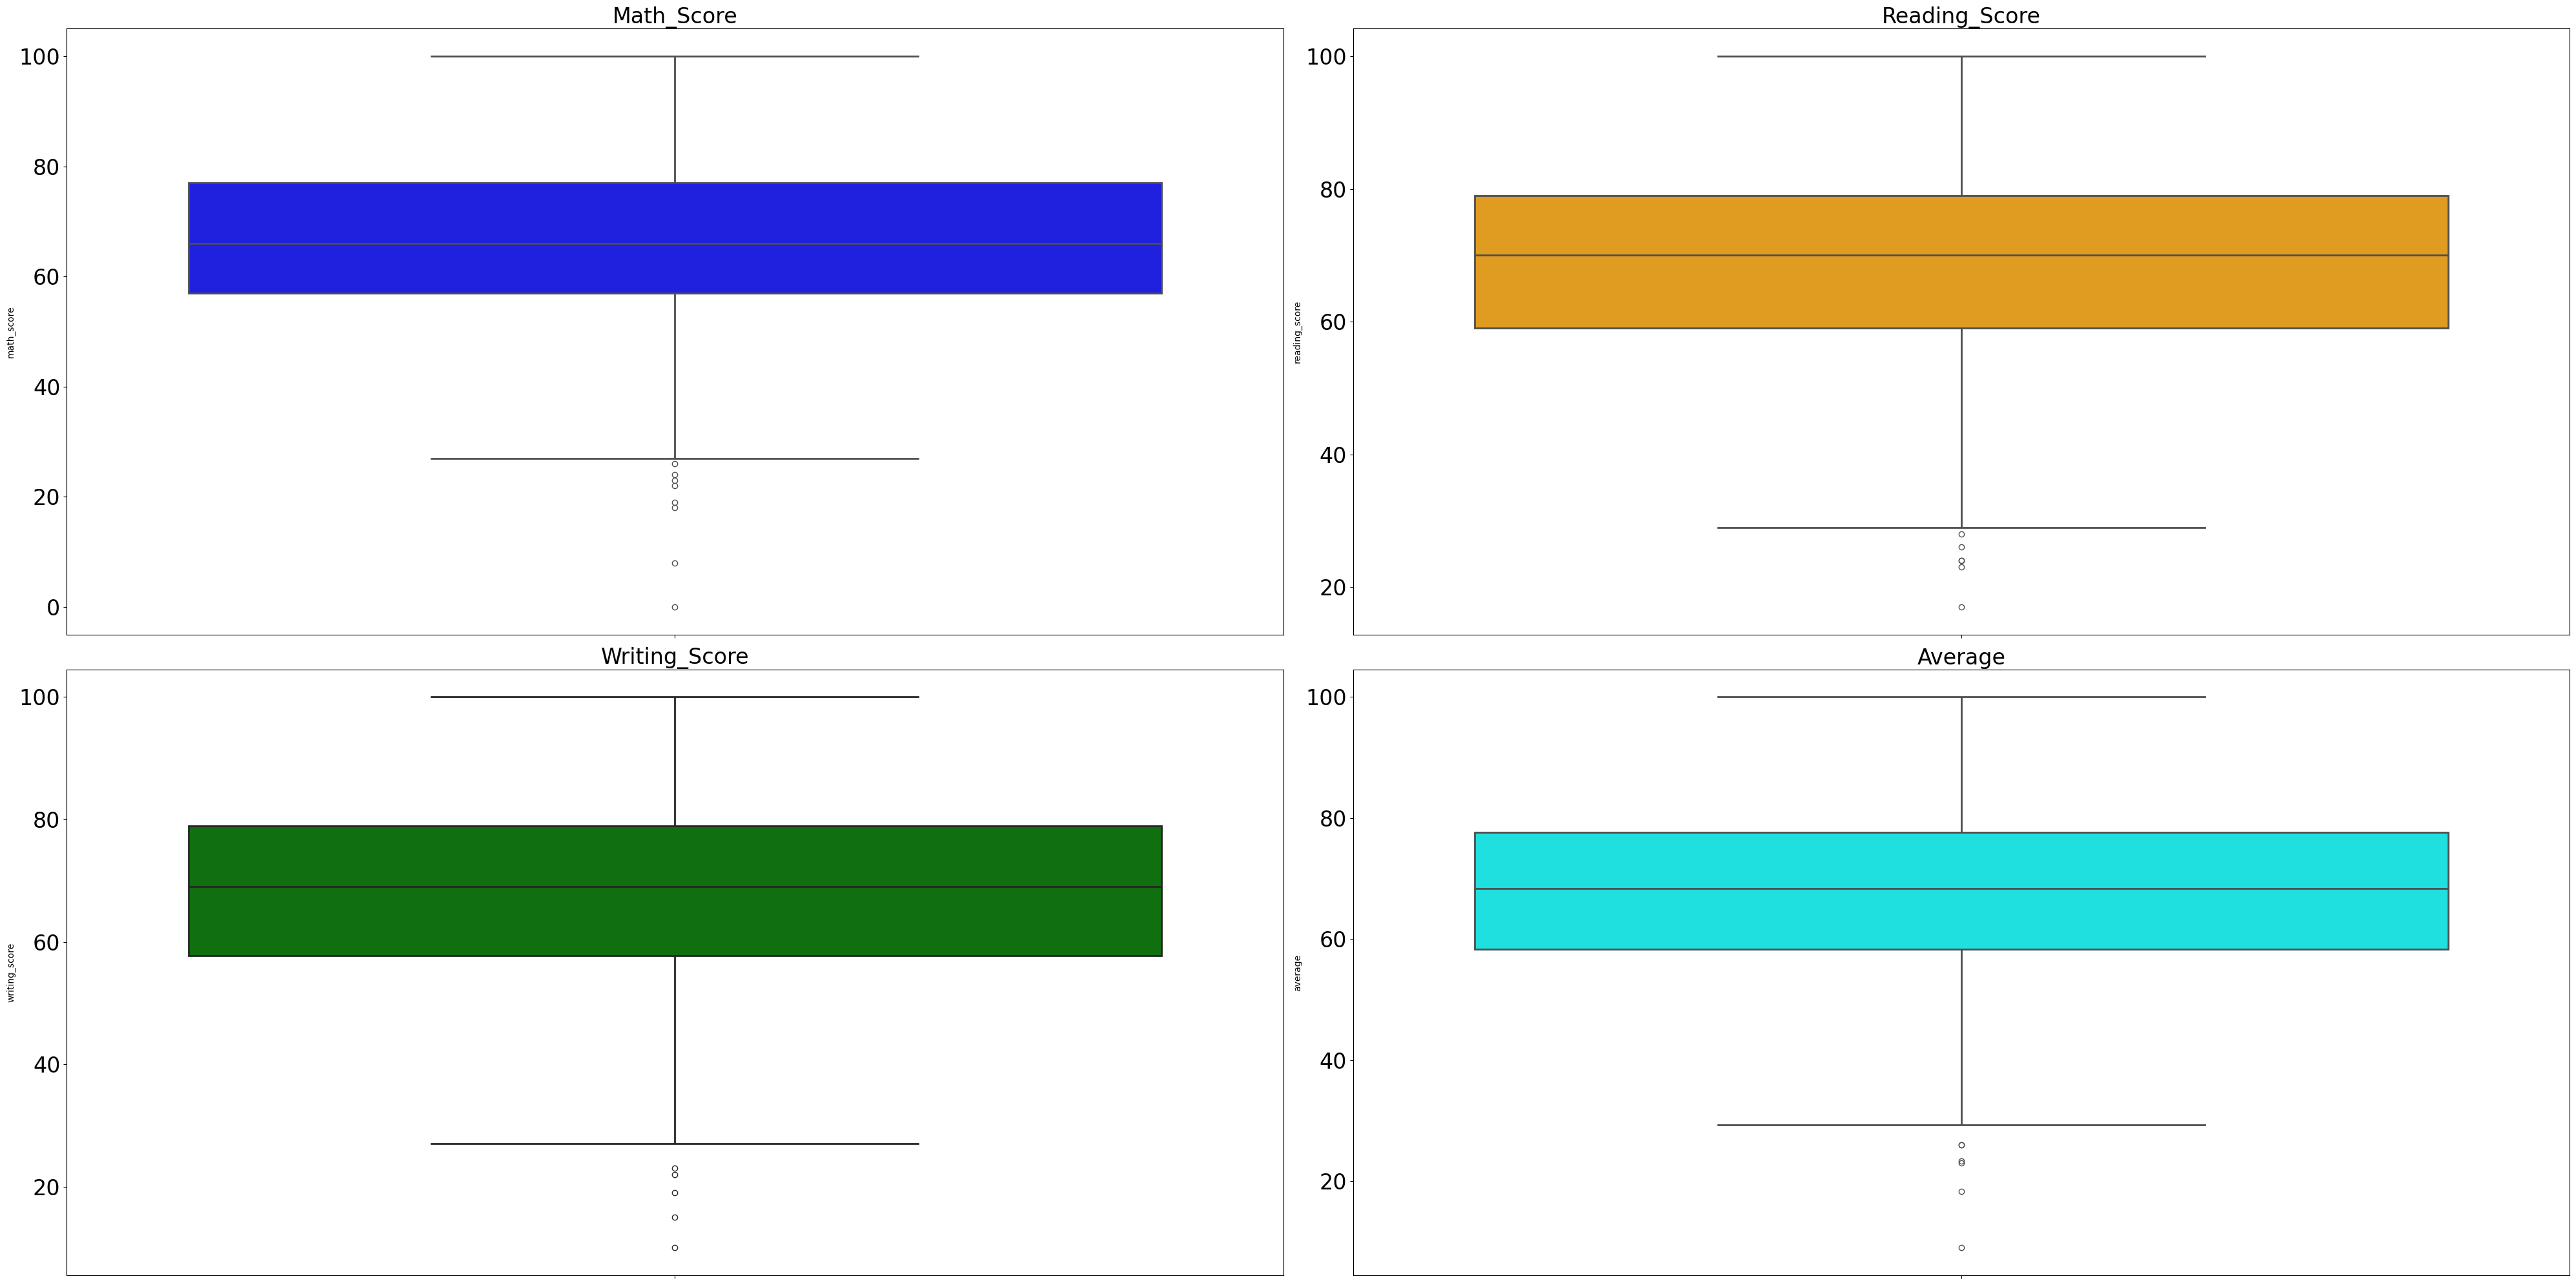

In [87]:
vars.refresh()
vars.numerical_var
graph.box_plot([x for x in vars.numerical_var if x != "total_score"], fontsize=24, linewidth=2, figsize=(40, 20))

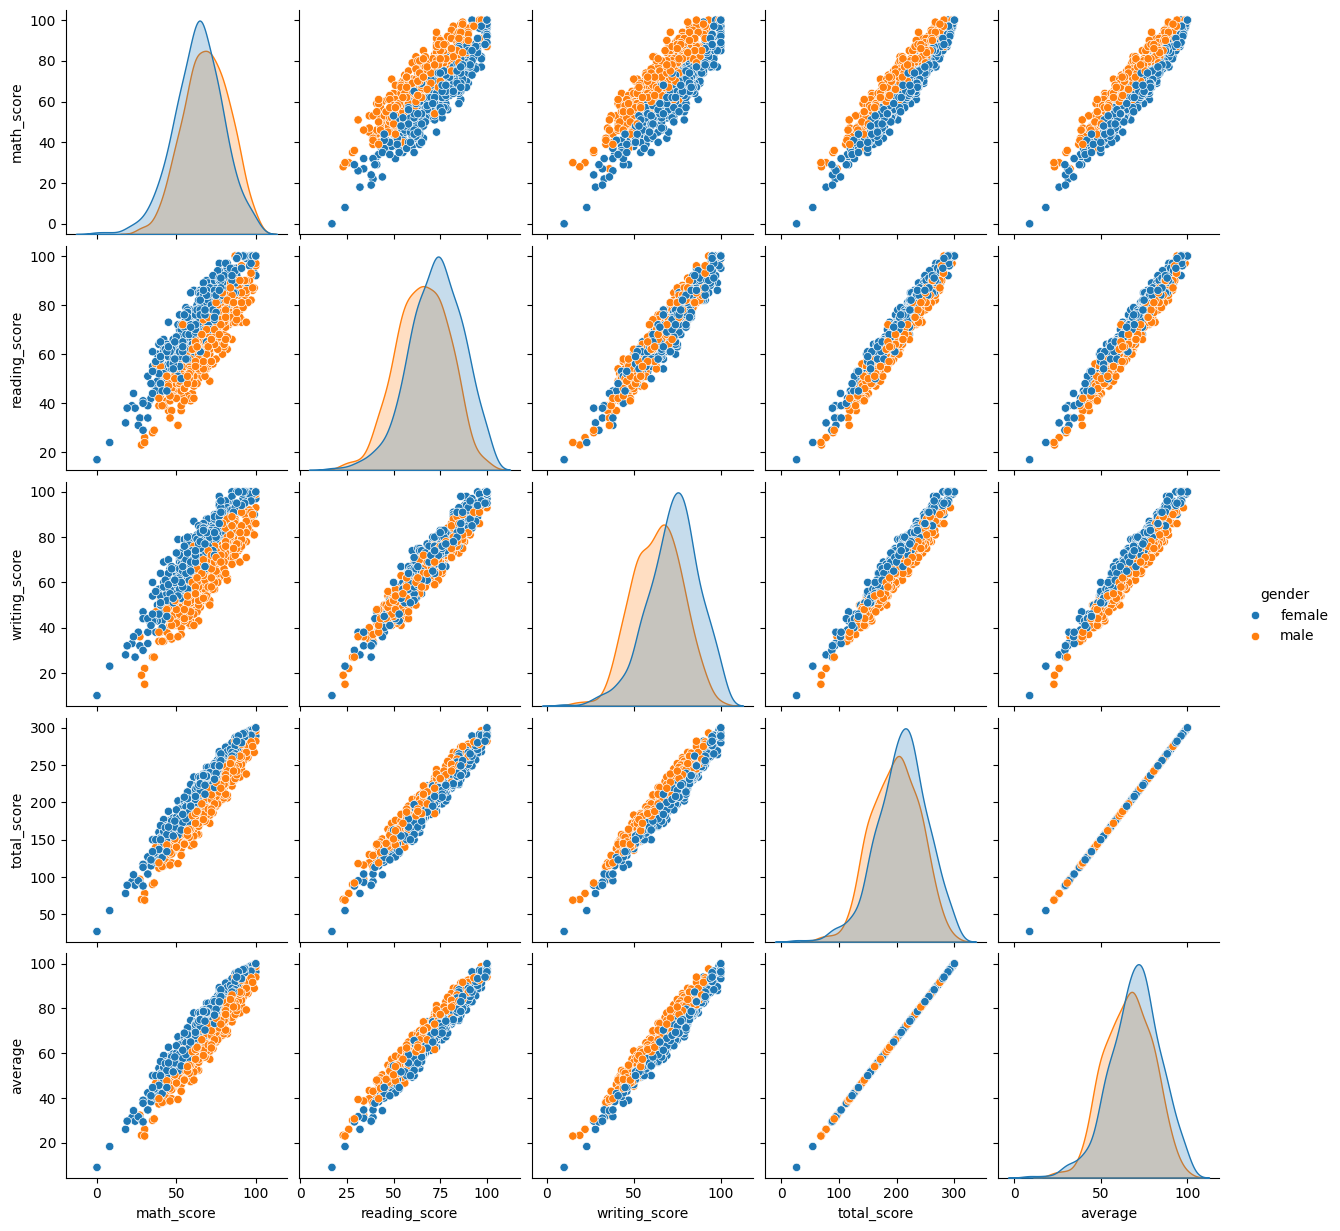

In [88]:
graph.pairplot('gender')

Insights 

- From the above plot it is clear that all the scores increase linearly with each other

In [89]:
vars.categorical_var

['gender',
 'race_ethnicity',
 'parental_level_of_education',
 'lunch',
 'test_preparation_course']

#### 5. Conclusions

- Student's Performance is related to race, parental level of education, lunch
- Females lead in pass percentage and also are top scorers
- Students' performance is not much related with test preparation course
- Finishing preparation course is beneficial